# Attenuator calibration and throughput noise lab

**Questions for this bench session:** how do valid high-signal points compare with the saved
firmware fit, how long does the optical path take to stabilize, and do repeated fixed voltages
reproduce a reversal or a noise difference?

The model remains the existing **erf shutter model, leakage floor and Chebyshev correction**.
Section 2 evaluates the captured firmware coefficients; it performs no host refit.

1. [Setup and raw calibration](#setup): archive measurements before analysis.
2. [Firmware fit and measured residuals](#fits): include readings brighter than the reference.
3. [Fixed-setting acquisitions](#acquire): scans, redistribution and the DAC1 reversal repeat.
4. [Noise and throughput](#noise): dark baseline, settling, scatter, spectra and recorded routes.
5. [Drive-voltage evidence](#scope): local slopes and bandwidth assumptions.

**Section 2 reads saved data only.** Use the workspace `.venv` kernel. Hardware cells use the
setup flags; inspect their current values before Run All.
The laser-on approval flags must remain false until the operator approves that acquisition.
No exploratory coefficients are uploaded. The optional embedded calibration does install its own
accepted fit in RAM, even with `persist=False`; it may drive the laser up to 100%.

Raw files created during acquisition live in `tools/atten_noise_data/`. Keep these with the setup
metadata: a plot or coefficient tuple alone cannot support a later refit.

## Starting evidence

The September 21 run uses the assembled YJ path and a replacement FVOA. Its calibration contains
many valid open-region readings above the selected reference. Their negative relative dB are
measurement residuals; they are not negative commanded attenuation or proof of a defective device.

The subsequent noise capture contains a clipped startup dark, long illuminated transients and a
DAC1 brightening between its previous 52.5 and 55 dB settings. The analysis below derives a baseline
from the recorded dark trace and retains the complete time history. Fixed DAC settings alone do not
establish stationarity. A second long transition occurs well after laser turn-on.

The earlier bypass experiment used different routing and hardware. Its 25 dB/direct-return
assumptions do not describe this assembled path. Use each capture's setup notes and route factors.
The observed noise asymmetry motivates a controlled repeat; it does not identify which FVOA,
drive capacitor, laser or detector contributes the variation.

<a id="setup"></a>
## 1. Setup

`laser(value=0)` now retains driver readiness. Cleanup uses `laser(stop=True)` for explicit shutdown.
The new firmware/helper must be used together; restart the kernel after updating the helper.

Keep the launch power fixed during each illuminated sequence. Equal-total allocations compare
different local FVOA slopes at approximately the same detector level. Repeated reference settings
reveal drift and hysteresis. Record physical changes in `SETUP_NOTES` before each acquisition.

In [1]:
from pathlib import Path
from dataclasses import asdict, is_dataclass
from datetime import datetime, timezone
import json
import math
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy import signal

TOOLS = next(p.resolve() for p in (Path.cwd(), Path.cwd() / "tools", Path.cwd() / "hispec-tib/tools") if (p / "hispec_fibpcb.py").is_file())
sys.path.insert(0, str(TOOLS))
import hispec_fibpcb as hspcb

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.2})
DATA_DIR = TOOLS / "atten_noise_data"
BROKER, DEVICE = "hispec.caltech.edu", "hsfib-tib"
LASER, CHANNEL, OUTPUT, FIBER = "1028y", "yj", "yj_ao", "M"
CONNECT = True
FETCH_CALIBRATION = True
RUN_AUTOCAL = True
AUTOCAL_LASER_APPROVED = True  # Includes the firmware's possible 100% laser setting.
RUN_NOISE_SEQUENCE = True
NOISE_LASER_APPROVED = True

CALIBRATION_FILE = None  # Path to a saved calibration .npz; or fetch retained PCB records.
NOISE_CSV = None        # Path to a saved noise CSV; acquired files are selected automatically.
HISTORICAL_CSV = None
SETUP_NOTES = "B side fully assembled; SW3 C FEI->5dB->FFLC MM Green; SW3 B AO->3dB->FFLC MM Yellow"
FLASHED_ADC_SPS = 64  # Enter only from a verified flashed configuration; 20 Hz stream != ADC SPS.
EXTERNAL_LASER_POWER_MW = None  # Optional simultaneous/associated power-meter value, before static loss.
EFFECTIVE_GAIN_V_PER_A = 2.0e10  # Nominal YJ ADC-input gain, including divider; use saved/live settings.

calibration = None
cal_context = {}
last_noise_csv = None

### Optional connection and retained-data retrieval

Connection does not request emission. Reruns reuse the existing client; snapshots avoid the all-bank temperature sweep. The snapshot records firmware identity, calibration, dark,
response settings and temperature. `FLASHED_ADC_SPS=None` means unknown: the historical report's
64 SPS build and the documented 250 SPS default do not establish what is running now.

Fetching retained calibration records does not start a sweep. A new sweep is a separate action below.

In [2]:
def json_value(value):
    """Encode measurement metadata without pickle or repr-dependent parsing."""
    if is_dataclass(value):
        return json_value(asdict(value))
    if isinstance(value, dict):
        return {str(k): json_value(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_value(v) for v in value]
    if isinstance(value, np.ndarray):
        return json_value(value.tolist())
    if isinstance(value, np.generic):
        return json_value(value.item())
    if isinstance(value, float) and not np.isfinite(value):
        return None
    return str(value) if isinstance(value, Path) else value


def setup_snapshot(client):
    """Read experiment context; these queries do not request laser emission."""
    return json_value(dict(utc=datetime.now(timezone.utc).isoformat(), setup=SETUP_NOTES,
        laser=LASER, channel=CHANNEL, output=OUTPUT, fiber=FIBER, flashed_adc_sps=FLASHED_ADC_SPS,
        external_laser_power_mw=EXTERNAL_LASER_POWER_MW,
        status=client.status(), coeff=client.atten_coeff(LASER), atten=client.atten(LASER),
        laser_status=client.laser(LASER), laser_settings=client.laser_settings(LASER),
        pd_settings=client.pd_settings(CHANNEL), dark=client.pd_dark(CHANNEL)))


def save_calibration(dataset, context):
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
    path = DATA_DIR / f"cal_{LASER}_{stamp}.npz"
    np.savez_compressed(path, records=dataset.records,
                        metadata=np.array(json.dumps(json_value(dict(meta=dataset.meta, context=context)), allow_nan=False)))
    print("Raw calibration saved:", path)
    return path


def load_calibration(path):
    with np.load(path, allow_pickle=False) as archive:
        records = archive["records"].copy()
        saved = json.loads(str(archive["metadata"]))
    for item in saved["meta"]:
        if "fits" in item:
            item["fits"] = {key: hspcb.AttenuatorFitMetrics(**value) for key, value in item["fits"].items()}
    return hspcb.AttenuatorCalibrationDataset(records, tuple(saved["meta"])), saved["context"]


def dark_is_usable(result):
    """Check captured dark statistics before illumination or offline baseline use; no I/O."""
    result = json_value(result)
    window = result.get("dark", {})
    values = np.array([window.get(key) for key in ("mean_mv", "rms_mv", "min_mv", "max_mv")], dtype=float)
    return bool(not result.get("pending", False) and np.all(np.isfinite(values))
                and values[1] >= 0 and values[3] < hspcb.PD_ADC_USABLE_MV)

In [3]:
if CONNECT:
    pcb = globals().get('pcb', hspcb.HispecFibPcb(BROKER, device=DEVICE, connect=True))
    live_context = setup_snapshot(pcb)
    display(live_context)
if CALIBRATION_FILE is not None:
    calibration, cal_context = load_calibration(CALIBRATION_FILE)
if FETCH_CALIBRATION:
    if pcb is None:
        raise RuntimeError("Connect first to fetch retained calibration records.")
    if pcb.atten_calibrate().state == "running":
        raise RuntimeError("Wait for acquisition to finish before retrieving a consistent dataset.")
    calibration = pcb.atten_calibration_data(physical="all")
    cal_context = dict(live_context) if CONNECT else setup_snapshot(pcb)
    CALIBRATION_FILE = save_calibration(calibration, cal_context)
if calibration is not None:
    display(calibration, calibration.bridge_table())
else:
    print("No raw calibration loaded. Fit cells will skip until a saved/fetched sweep is available.")

{'utc': '2026-09-22T18:45:38.247045+00:00',
 'setup': 'B side fully assembled; SW3 C FEI->5dB->FFLC MM Green; SW3 B AO->3dB->FFLC MM Yellow',
 'laser': '1028y',
 'channel': 'yj',
 'output': 'yj_ao',
 'fiber': 'M',
 'flashed_adc_sps': 64,
 'external_laser_power_mw': None,
 'status': {'fw': 'be6cbbb85589-dirty',
  'boots': 71,
  'board': 'tib',
  'board_ok': True,
  'mems_switches': 8,
  'relay_err': 0,
  'amb_c': 19.938,
  'pd_on_s': 0,
  'laserbank_on_s': 451,
  'lastcmd': {'name': 'laser', 'src': 'mqtt', 't_ms': 72961513},
  'ip': None,
  'lasers': [],
  'attens': []},
 'coeff': {'dac1': {'fvoa_50pct_mv': 3251.40338798,
   'slope_inv_fvoa_mv': 0.00306571168858,
   'max_atten_db': 80.9878692627,
   'max_calibrated_db': 55.0,
   'gain': 1.533,
   'correction_coeff': [-4.48303556,
    11.4890594,
    -6.4737525,
    12.1752758,
    -1.59990907,
    2.38193679],
   'rms_db': 0.105802658},
  'dac2': {'fvoa_50pct_mv': 2942.78698545,
   'slope_inv_fvoa_mv': 0.00231191159688,
   'max_atten_db

Raw calibration saved: /Users/jibailey/src/hispec-zephyr-mlang/hispec-tib/tools/atten_noise_data/cal_1028y_20260922T184539_435852Z.npz


AttenuatorCalibrationDataset(records=0, physicals=(), counts=())

,physical,bridge_index,boundary_index,before_record,after_record,from_segment,to_segment,sweep_mv,other_before_mv,other_after_mv,signal_before_mv,signal_after_mv,ratio,ratio_rel_var


In [41]:
pcb.mems_route('yj_laser','yj_ao'), pcb.mems_route('yj_mm', 'yj_pd')
for r in pcb.mems_route().active_routes:
    if r.name.startswith('yj'):
        print(f'{", ".join(r.value)} ->  {r.name}')
pcb.mems()

yj_1430, yj_laser ->  yj_ao
no source ->  yj_fei
yj_mm ->  yj_pd


(MemsSwitchState(name='yj_forward_retro', state='A', duty_cycle=1),
 MemsSwitchState(name='yj_laser_cal', state='A', duty_cycle=1),
 MemsSwitchState(name='yj_ao_fei', state='A', duty_cycle=1),
 MemsSwitchState(name='hk_forward_retro', state='A', duty_cycle=1),
 MemsSwitchState(name='hk_laser_cal', state='A', duty_cycle=1),
 MemsSwitchState(name='hk_ao_fei', state='A', duty_cycle=1),
 MemsSwitchState(name='yj_mm_sm', state='A', duty_cycle=1),
 MemsSwitchState(name='hk_mm_sm', state='A', duty_cycle=1))

In [42]:
laser='1028y'
pcb.atten(laser, value1_db=40, value2_mv=0)
pcb.laser(laser,value=.01)
time.sleep(.5)
print(pcb.pd('yj').yj.net_mv)
pcb.laser(laser,value=.0)

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=190.907 threshold_mv=10.000 uptime_ms=69741321
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=190.907 threshold_mv=10.000 uptime_ms=69741321


707.4171875


CommandOk(status='ok')

### Optional new embedded acquisition

The firmware owns acquisition and bridging; there is no duplicate Python state machine here.
This cell changes routes, laser output, DAC positions, and possibly the installed **RAM** coefficients.
It requests `persist=False`. Review the optical setup before approving the possible full-power sweep.
On completion or interruption, it attempts laser-off and retains whatever raw records are available.
An acquisition/fit failure stays visible rather than being converted into a successful calibration.

In [5]:
pcb.pd_settings('yj',autooff_s=600)
pcb.pd_settings('hk',autooff_s=600)
pcb.pd()

PhotodiodeValues(
  yj=PhotodiodeChannelValues(
  raw=-16,
  mv=-1,
  net_mv=1.16719,
  net_err_mv=0.327692,
  power_uw=6.2752e-08,
  power_err_uw=1.76179e-08,
  dark_mv=-2.16719,
  dark_err_mv=0.0511769,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=-0.95,
  mean_net_mv=1.21719,
  rms_mv=0.497494,
  mean_net_err_mv=0.165436,
  min_mv=-1.6875,
  max_mv=0,
  power_uw=6.54402e-08,
  power_err_uw=8.89441e-09
),
  pd_powered=True,
  pd_on_s=3469
),
  hk=PhotodiodeChannelValues(
  raw=13,
  mv=0.8125,
  net_mv=-1.32187,
  net_err_mv=0.945083,
  power_uw=0,
  power_err_uw=1.63163e-06,
  dark_mv=2.13437,
  dark_err_mv=0.147597,
  window=PhotodiodeWindow(
  duration_ms=500,
  failed_samples=0,
  mean_mv=0.83125,
  mean_net_mv=-1.30313,
  rms_mv=0.0286411,
  mean_net_err_mv=0.330037,
  min_mv=0.8125,
  max_mv=0.875,
  power_uw=0,
  power_err_uw=5.69792e-07
),
  pd_powered=True,
  pd_on_s=0
)
)

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=hk fixed_rms_mv=25.635 threshold_mv=10.000 uptime_ms=7273238


In [23]:
PERSIST_CALIBRATION=False
LASER='1028y'
if RUN_AUTOCAL:
    if pcb is None or not AUTOCAL_LASER_APPROVED:
        raise RuntimeError("Connect and obtain operator approval for the embedded laser sweep first.")
    cal_context = setup_snapshot(pcb)
    finished = False
    try:
        print(f'High atten and stop lasers for {LASER} atten auto cal')
        for l in ('1028y','1270j', '1430yj'):
            pcb.laser(l, stop=True)
        pcb.atten(LASER, value1_mv=3300,value2_mv=3300)
        pcb.pd()  # Power the detector before dark/calibration.
        time.sleep(5)
        print(f'Taking Dark {CHANNEL}')
        dark = pcb.pd_dark(CHANNEL, duration_ms=2000, persist=False)
        dark_deadline = time.monotonic() + 15
        while dark.pending:
            if time.monotonic() >= dark_deadline:
                raise TimeoutError("Dark acquisition did not complete.")
            time.sleep(.25)
            dark = pcb.pd_dark(CHANNEL)

        cal_context["dark"] = json_value(dark)  # Save even a rejected dark in cleanup.
        if not dark_is_usable(dark):
            raise RuntimeError("Dark statistics are nonfinite or saturated; inspect detector startup before illumination.")

        pd_data = pcb.pd()
        print(f"YJ dark: {pd_data.yj.dark_mv:.3f}±{pd_data.yj.dark_err_mv:.3f} mV\n"
              f"HJ dark: {pd_data.hk.dark_mv:.3f}±{pd_data.hk.dark_err_mv:.3f} mV")
        
        print(f'Callibrating Atten {LASER}')
        state = pcb.atten_calibrate(LASER, output=OUTPUT, fiber=FIBER, dwell_ms=550, persist=PERSIST_CALIBRATION)
        deadline = time.monotonic() + 900
        while state.state == "running":
            if time.monotonic() >= deadline:
                raise TimeoutError("Calibration exceeded 15 minutes.")
            print(f"{state.physical}: {state.complete_pct:g}%", end="\r")
            time.sleep(3)
            state = pcb.atten_calibrate()
        finished = True
        display(state)
    finally:
        try:
            if not finished:
                pcb.atten_calibrate_stop()
        finally:
            try:
                pcb.laser(LASER, stop=True)
            finally:
                calibration = pcb.atten_calibration_data(physical="all")
                CALIBRATION_FILE = save_calibration(calibration, cal_context)
else:
    print("New embedded acquisition disabled.")

High atten and stop lasers for 1028y atten auto cal
Taking Dark yj
YJ dark: -0.820±0.058 mV
HJ dark: 2.134±0.148 mV
Callibrating Atten 1028y
dac1: 0%

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=510.142 threshold_mv=10.000 uptime_ms=8122271


dac1: 35%

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=12.672 threshold_mv=10.000 uptime_ms=8182271


dac2: 83%

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=10.273 threshold_mv=10.000 uptime_ms=8243921


dac2: 88%

AttenuatorCalibrationStatus(
  state='complete', mode='tib_auto', physical='dac2', point='99/128', complete_pct=100,
  mv=3300, other_mv=4.876, t_ms=550, error=0, fit='ok',
  dac1=AttenuatorFitMetrics(accepted=True, points=58, fvoa_50pct_mv=3251.4, slope_inv_fvoa_mv=0.00306571, max_atten_db=80.9879, max_calibrated_db=55, max_atten_sigma_db=0.288675, corr=0.999972, rms_db=0.105803, max_abs_db=0.250366, correction_coeff=(-4.48304, 11.4891, -6.47375, 12.1753, -1.59991, 2.38194), ),
  dac2=AttenuatorFitMetrics(accepted=True, points=58, fvoa_50pct_mv=2942.79, slope_inv_fvoa_mv=0.00231191, max_atten_db=80.6133, max_calibrated_db=55, max_atten_sigma_db=0.288675, corr=0.999941, rms_db=0.159149, max_abs_db=0.464914, correction_coeff=(-43.9502, -88.9929, -59.3713, -42.2931, -12.3475, -6.99734), )
)

Raw calibration saved: /Users/jibailey/src/hispec-zephyr-mlang/hispec-tib/tools/atten_noise_data/cal_1028y_20260921T233504_121061Z.npz


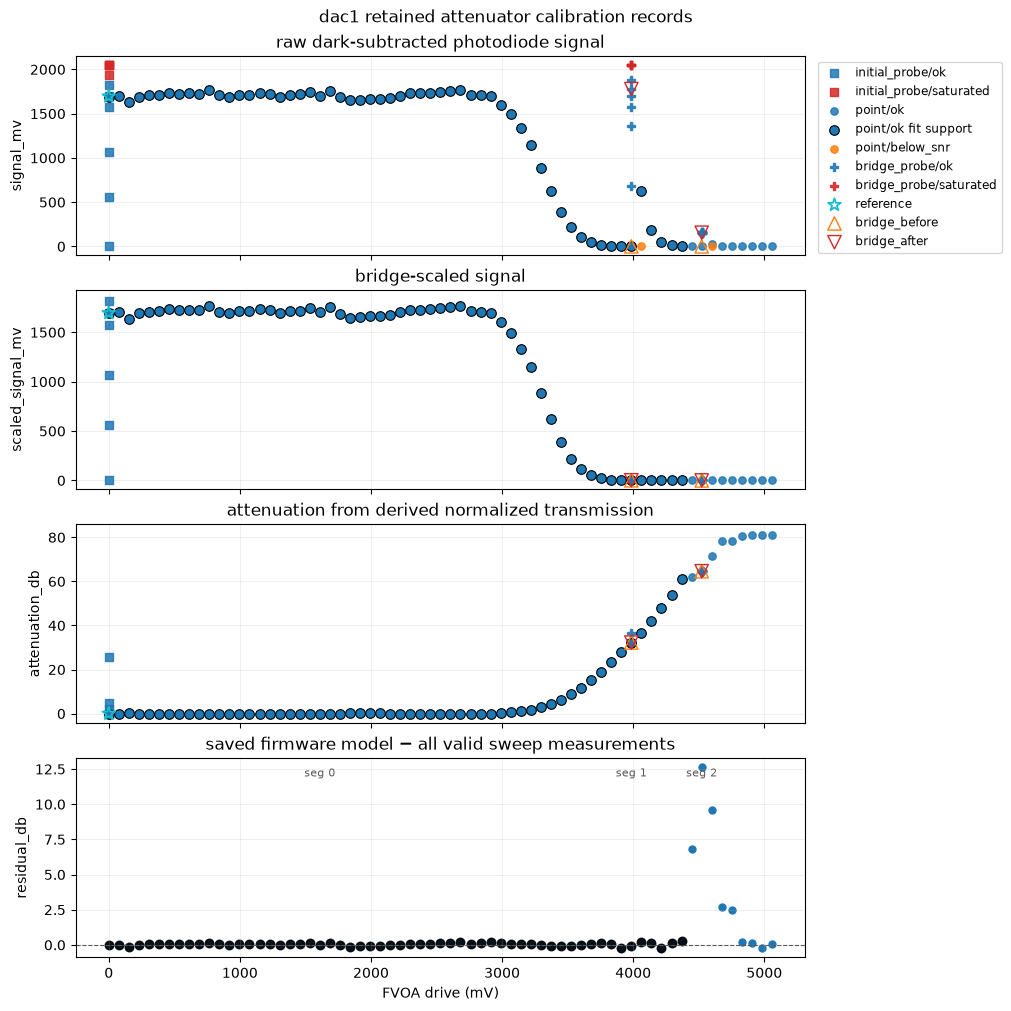

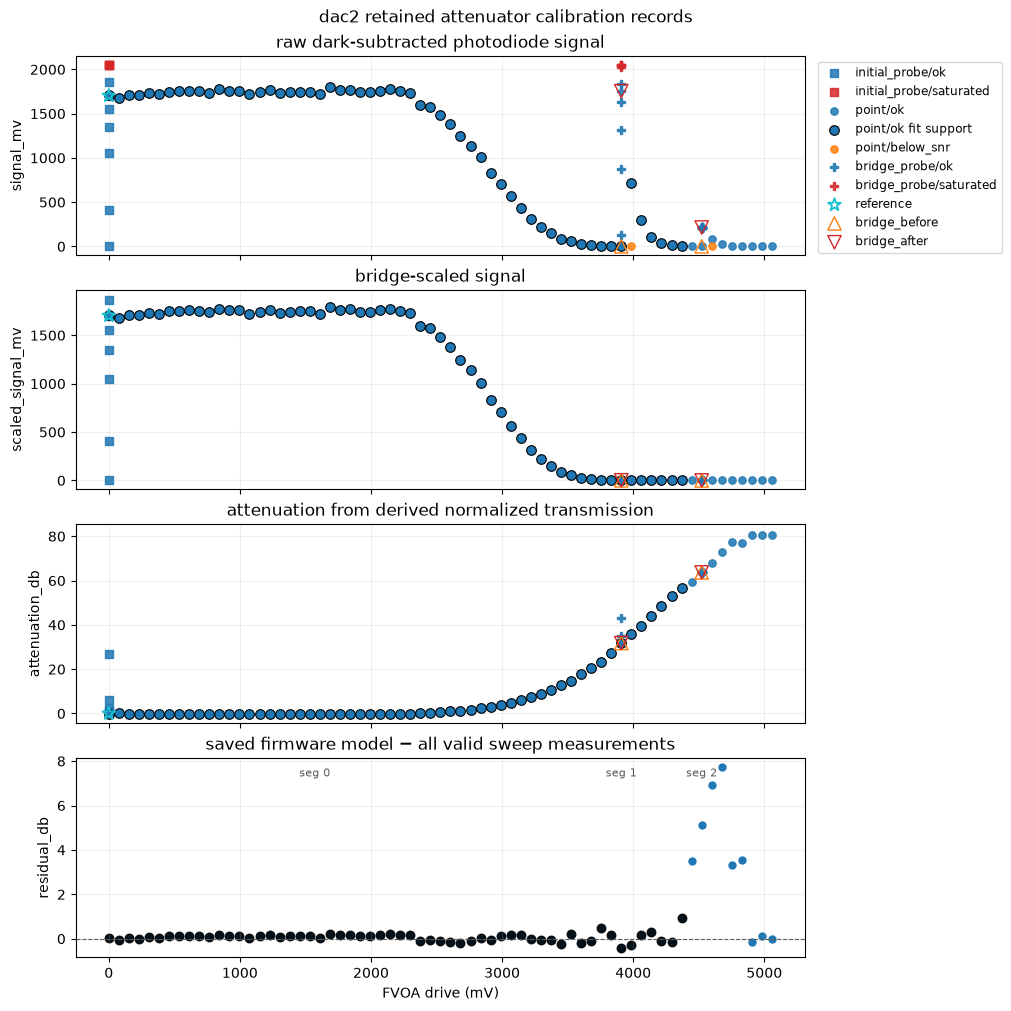

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=hk fixed_rms_mv=24.054 threshold_mv=10.000 uptime_ms=8721588
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=87.541 threshold_mv=10.000 uptime_ms=8722571


In [25]:
calibration.plot_physical("dac1");
calibration.plot_physical("dac2");

<a id="fits"></a>
## 2. Firmware fit and calibrated range

This section displays **the firmware fit saved with this capture**. The table and curve use
its returned coefficients and metrics; there is no host refit. The filename identifies the
source. Loading a capture does not establish which coefficients are currently on the PCB.

New firmware fits the existing erf + leakage-floor model and Chebyshev correction through the
first usable measurement **above 55 dB**. That extra point supports the boundary. It refits
with fewer leading correction terms when the final curve fails validation, with a base-only
fit as the last fallback. Six coefficient slots remain available.

`max_calibrated_db` bounds normal automatic operation. The correction joins continuously to
the rough continuation above it. Reported RMS, worst residual and correlation describe
fitting-support measurements at or below that limit, including negative measured dB; the above-limit support point is excluded from those metrics.
Firmware checks the final curve on a 1 mV grid, at fitting-support voltages and at the join.
Older captures retain the coefficients and metrics their firmware actually reported.

All valid sweep readings are shown, including transmission equal to or above the measured
reference. The separate offline RMS scores every valid in-range measurement against the saved
model. Raw records lack per-point inclusion flags: support markers are only inferred when the
current-rule prefix count agrees with the captured fit count. A mismatch is labeled explicitly;
it does not change the saved fit or identify historical support by guesswork.

Run the imports and helper definitions in section 1, then this section; it needs no connection.
The chronological table shows initial probes and the first sweep reading, including both DAC
settings. In the raw plots, probes are squares and sweep points are circles; color indicates
classification. Multiple initial probes overlap at DUT voltage zero.

In [19]:
if CALIBRATION_FILE is None:
    raise ValueError("Set CALIBRATION_FILE to the saved .npz, or complete a calibration capture first.")
FIT_ARCHIVE = Path(CALIBRATION_FILE)
calibration, cal_context = load_calibration(FIT_ARCHIVE)
print("Firmware fit from this capture:", FIT_ARCHIVE.name)

Firmware fit from this capture: cal_1430yj_20260921T232905_868756Z.npz


if calibration is not None and len(calibration.records):
    for physical in ("dac1", "dac2"):
        if np.any(calibration.records.physical == physical):
            calibration.plot_physical(physical, x_axis="sweep_mv")
            plt.show()
    calibration

In [20]:
initial_rows = []
for physical in ("dac1", "dac2"):
    records = calibration.physical(physical).records
    meta = calibration._physical_meta(physical) or {}
    sweeps = records[records.event == "point"]
    first_sweep = int(sweeps.record[0]) if len(sweeps) else None
    for record in records:
        if record.event != "initial_probe" and int(record.record) != first_sweep:
            continue
        initial_rows.append(dict(physical=physical, record=int(record.record),
            event=str(record.event), classification=str(record.classification),
            reference=bool(meta.get("reference_valid") and record.record == meta.get("reference_record")),
            dut_mv=record.sweep_mv, companion_mv=record.other_mv, laser_pct=record.laser_pct,
            net_mean_mv=record.signal_mv, raw_peak_mv=record.max_mv))
display(pd.DataFrame(initial_rows).round(3))
print("Search target: raw peak <1850 mV; PD linearity limit: 2000 mV; ADC full scale: 2048 mV.")

,physical,record,event,classification,reference,dut_mv,companion_mv,laser_pct,net_mean_mv,raw_peak_mv
0,dac1,0,initial_probe,below_snr,False,0.0,3300.000,100.0,0.176,-0.125
1,dac1,1,initial_probe,saturated,False,0.0,1650.000,100.0,2048.806,2047.938
2,dac1,2,initial_probe,ok,False,0.0,2475.000,100.0,604.363,693.438
3,dac1,3,initial_probe,saturated,False,0.0,2062.500,100.0,2048.806,2047.938
4,dac1,4,initial_probe,saturated,False,0.0,2268.750,100.0,2048.806,2047.938
5,dac1,5,initial_probe,saturated,False,0.0,2371.875,100.0,1778.363,2028.812
6,dac1,6,initial_probe,ok,False,0.0,2423.438,100.0,1030.573,1187.688
7,dac1,7,initial_probe,ok,False,0.0,2397.656,100.0,1353.289,1527.438
8,dac1,8,initial_probe,ok,False,0.0,2384.766,100.0,1568.676,1778.750
9,dac1,9,initial_probe,ok,False,0.0,2378.320,100.0,1627.482,1915.562


Search target: raw peak <1850 mV; PD linearity limit: 2000 mV; ADC full scale: 2048 mV.


In [21]:
firmware_results, fit_rows = {}, []
fits = next((item["fits"] for item in calibration.meta if "fits" in item), {})
derived = calibration.derived()
for physical in ("dac1", "dac2"):
    fit = fits.get(physical)
    firmware = calibration._fit_coeff_for_physical(physical)
    if fit is None or firmware is None:
        fit_rows.append(dict(physical=physical, accepted=False, model="No valid captured fit"))
        continue
    gain = float(cal_context.get("coeff", {}).get(physical, {}).get("gain", hspcb.ATTENUATOR_DEFAULT_GAIN))
    firmware = (*firmware[:3], gain, firmware[4], firmware[5])
    points = derived[(derived.physical == physical) & (derived.event == "point")
                     & (derived.classification == "ok") & np.isfinite(derived.db)]
    support = np.asarray(points.included, dtype=bool)
    support_known = bool(fit.points and np.sum(support) == fit.points)
    limit = fit.max_calibrated_db
    # Match firmware's measured-dB precision without changing the captured metrics.
    in_range = (np.asarray(points.db, dtype=np.float32) <= np.float32(limit)
                if limit is not None else np.zeros(len(points), dtype=bool))
    residual = hspcb._atten_db_from_coeff(firmware, points.sweep_mv)-points.db
    terms = max((i+1 for i,c in enumerate(firmware[4]) if c != 0), default=0)
    model_name = f"base + {terms}-term Chebyshev" if terms else "base only"
    grid = np.arange(0, hspcb.ATTENUATOR_DRIVE_MAX_MV+1)
    curve = hspcb._atten_db_from_coeff(firmware, grid)
    finite = bool(np.all(np.isfinite(curve)))
    fit_rows.append(dict(physical=physical, accepted=fit.accepted, model=model_name,
        captured_fit_points=fit.points, support_membership="inferred" if support_known else "unavailable: count mismatch",
        all_valid_in_range=int(np.sum(in_range)), max_calibrated_db=limit,
        leakage_floor_db=fit.max_atten_db, firmware_rms_db=fit.rms_db,
        offline_all_valid_rms_db=float(np.sqrt(np.mean(residual[in_range]**2))) if np.any(in_range) else np.nan,
        firmware_worst_db=fit.max_abs_db, firmware_correlation=fit.corr,
        monotonic_grid=finite and bool(np.all(np.diff(curve) >= -1e-5)),
        nonnegative_grid=finite and bool(np.min(curve) >= 0)))
    firmware_results[physical] = dict(points=points, support=support, in_range=in_range,
        support_known=support_known, coefficients=firmware, limit=limit, model_name=model_name)
fit_table = pd.DataFrame(fit_rows).round(3)
display(fit_table.astype(object).where(pd.notna(fit_table), "—"))
print("Firmware metrics are saved values. Offline RMS uses all valid in-range measurements; no refit.")

,physical,accepted,model,captured_fit_points,support_membership,all_valid_in_range,max_calibrated_db,leakage_floor_db,firmware_rms_db,offline_all_valid_rms_db,firmware_worst_db,firmware_correlation,monotonic_grid,nonnegative_grid
0,dac1,True,base + 6-term Chebyshev,60,inferred,58,47.263,47.735,0.261,0.261,0.947,1.0,True,True
1,dac2,True,base + 6-term Chebyshev,61,inferred,59,47.994,48.481,0.224,0.224,0.895,1.0,True,True


Firmware metrics are saved values. Offline RMS uses all valid in-range measurements; no refit.


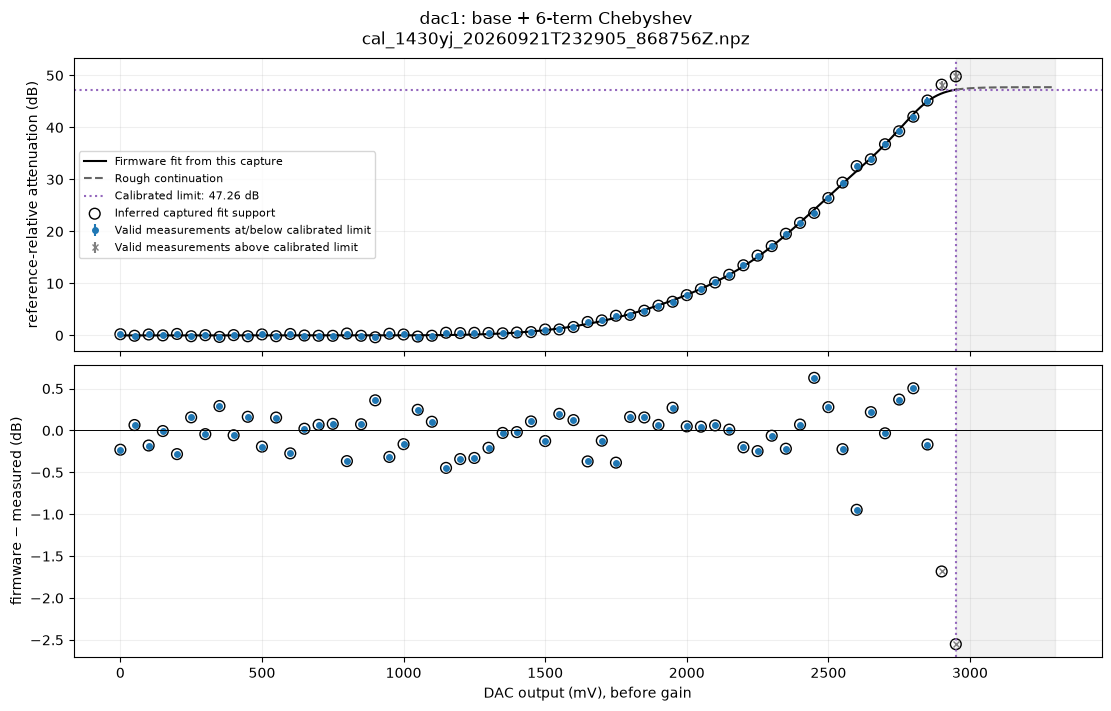

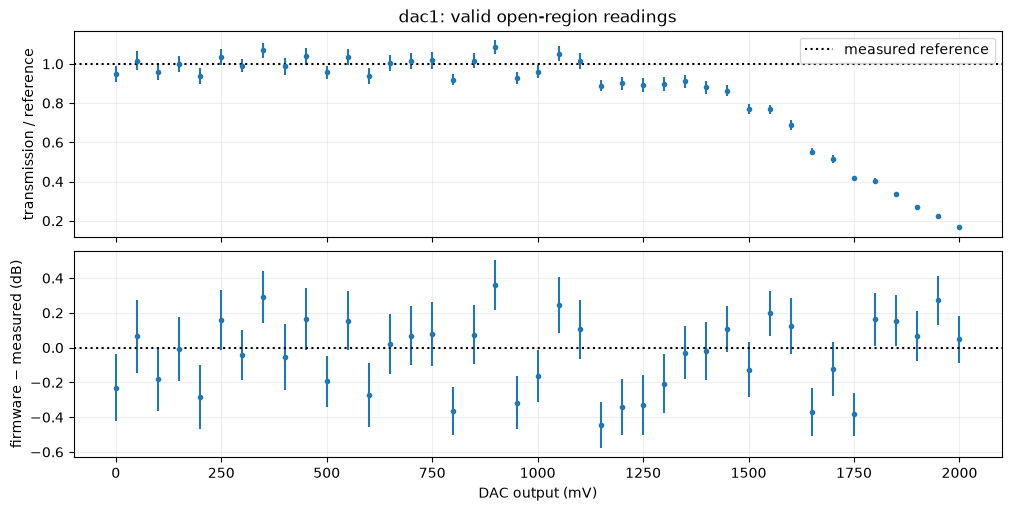

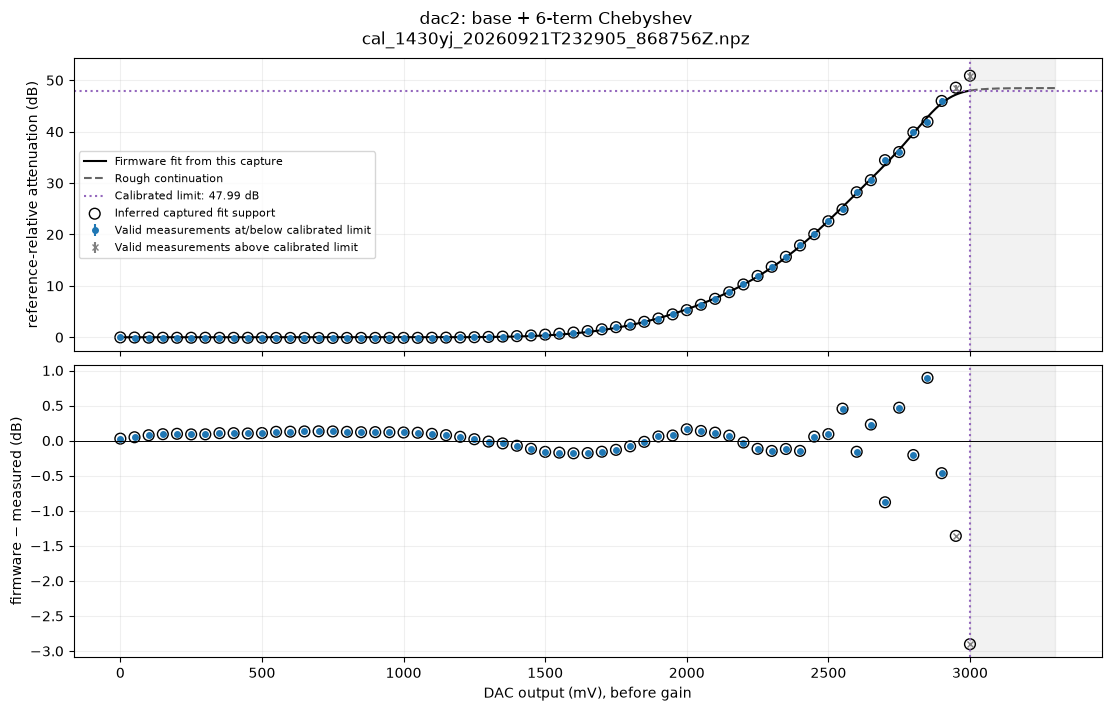

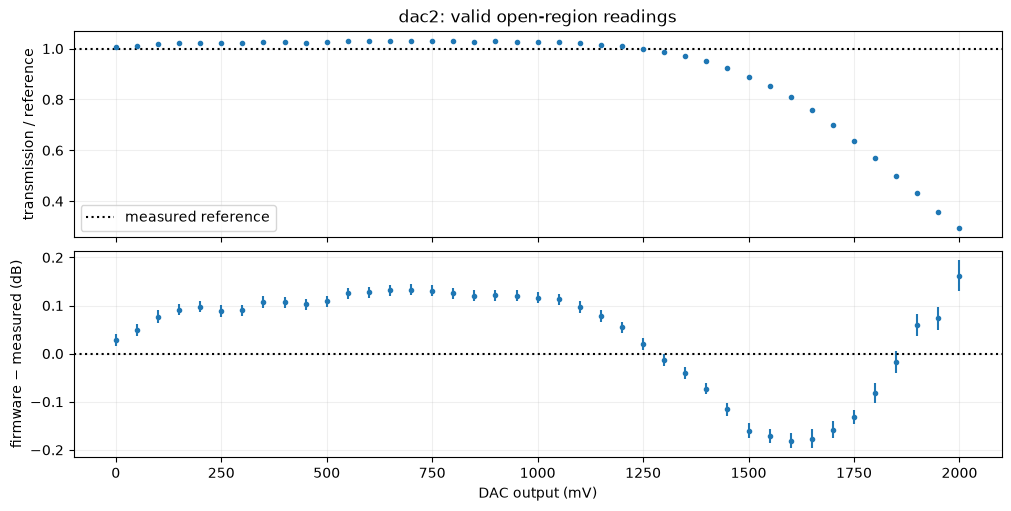

In [22]:
for physical, result in firmware_results.items():
    points, firmware = result["points"], result["coefficients"]
    support, in_range, limit = result["support"], result["in_range"], result["limit"]
    grid = np.arange(0, hspcb.ATTENUATOR_DRIVE_MAX_MV+1, dtype=float)
    curve = hspcb._atten_db_from_coeff(firmware, grid)
    boundary_mv = None
    if limit is not None:
        crossing = np.flatnonzero(curve >= limit)
        if len(crossing):
            k = int(crossing[0])
            boundary_mv = float(np.interp(limit, curve[max(0,k-1):k+1], grid[max(0,k-1):k+1]))
            grid = np.unique(np.r_[grid, boundary_mv])
            curve = hspcb._atten_db_from_coeff(firmware, grid)
    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, layout="constrained")
    inside = grid <= boundary_mv if boundary_mv is not None else np.ones(len(grid), dtype=bool)
    axes[0].plot(grid[inside], curve[inside], color="black", label="Firmware fit from this capture")
    if boundary_mv is not None:
        outside = grid >= boundary_mv
        axes[0].plot(grid[outside], curve[outside], "--", color="black", alpha=.6, label="Rough continuation")
        axes[0].axhline(limit, color="tab:purple", ls=":", label=f"Calibrated limit: {limit:.2f} dB")
        for ax in axes:
            ax.axvline(boundary_mv, color="tab:purple", ls=":")
            ax.axvspan(boundary_mv, grid[-1], color="gray", alpha=.1)
    residual = hspcb._atten_db_from_coeff(firmware, points.sweep_mv)-points.db
    for mask, marker, color, label in [
        (in_range, "o", "tab:blue", "Valid measurements at/below calibrated limit"),
        (~in_range, "x", "gray", "Valid measurements above calibrated limit")]:
        if not np.any(mask):
            continue
        axes[0].errorbar(points.sweep_mv[mask], points.db[mask], yerr=points.db_err[mask],
                         fmt=marker, color=color, markersize=4, label=label)
        axes[1].plot(points.sweep_mv[mask], residual[mask], marker, color=color, markersize=4)
    if result["support_known"]:
        for ax, y in zip(axes, (points.db, residual)):
            ax.scatter(points.sweep_mv[support], y[support], s=60, facecolors="none",
                       edgecolors="black", label="Inferred captured fit support")
    else:
        axes[1].text(.02, .04, "Captured support unavailable: point counts disagree.", transform=axes[1].transAxes)
    axes[0].set(ylabel="reference-relative attenuation (dB)")
    axes[0].legend(fontsize=8)
    axes[1].axhline(0, color="black", lw=.7)
    axes[1].set(xlabel="DAC output (mV), before gain", ylabel="firmware − measured (dB)")
    fig.suptitle(f"{physical}: {result['model_name']}\n{FIT_ARCHIVE.name}")
    plt.show()

    # Zoom the open region so the full-range dB axis cannot hide reference offsets.
    early = points.sweep_mv <= 2000
    fig, axes = plt.subplots(2, 1, sharex=True, figsize=(10, 5), layout="constrained")
    axes[0].errorbar(points.sweep_mv[early], points.tx[early], yerr=points.tx_err[early], fmt=".")
    axes[0].axhline(1, color="black", ls=":", label="measured reference")
    axes[0].set(ylabel="transmission / reference", title=f"{physical}: valid open-region readings")
    axes[0].legend()
    axes[1].errorbar(points.sweep_mv[early], residual[early], yerr=points.db_err[early], fmt=".")
    axes[1].axhline(0, color="black", ls=":")
    axes[1].set(xlabel="DAC output (mV)", ylabel="firmware − measured (dB)")
    plt.show()

**Interpret the captured result directly.** A base-only result means no correction is active;
reduced-order results have zero high-order coefficient slots. `accepted` reports firmware's
fit decision, not an absolute accuracy guarantee. Compare its residuals with the plotted data.
The plot boundary is the corrected curve's calibrated limit, located to the 1 mV plotting grid.
A measured in-range point with an out-of-range prediction still contributes its full error.

`leakage_floor_db` is the existing `max_atten_db` parameter. Automatic operation is bounded by
`max_calibrated_db`; manual dB, linear and voltage commands retain access to the rough tail.
The noise acquisition below uses the installed firmware coefficients.

<a id="acquire"></a>
## 3. Acquire fixed-setting noise data

Select `PROGRAM` below. `atten_scan`, `repeat_levels` and `redistribute` command dB using the
installed coefficients. 

The sequence stops the selected laser, powers the detector, waits **five seconds**, then captures
a two-second dark. It saves and checks the dark statistics before illumination: a nonfinite result
or raw peak at/above the **2000 mV detector limit** stops the sequence. The ADC clips at **2048 mV**.
The setup must actually be dark; unrelated light is not controlled here.

`autolevel=False` holds the commanded laser and DAC settings. `measure_throughput` selects the
logical MEMS routes in the assembled path. Each record keeps raw/net ADC, acquisition timestamps,
firmware uncertainties and route factors. Metadata retains commands, returned DAC positions,
coefficients, dark results, setup notes and completion/error state.

After dark validation, **one throughput monitor runs continuously** through the recorded dark,
laser startup, every DAC command and every hold. It stops during final cleanup; it is not restarted
between steps. Its timeout and collector capacity cover the complete sequence.

Each hold is a time slice of that continuous capture. The sidecar records command brackets and
hold bounds using the collector's acquisition timestamps. These are observed sample boundaries,
not exact hardware-write times. Samples between holds have `step_index=-1`, `step_label="transition"`:
they remain in the full trace and CSV but are excluded from fixed-setting statistics. Settling
exclusions apply only to analysis; they never discard raw samples.

The complete collected record is saved after each step and during cleanup. If an illuminated
step reaches the **2000 mV detector limit**, including during its command transition, capture
continues for **one more second** and then advances to the next step, even if the signal recovers.
This never extends the normal hold duration. The step records `end_reason="overrange"`; all raw
samples remain available, and earlier clipping does not shorten later steps. The same continuous
monitor stays running. Clipped samples and intervals too short after settling remain excluded
from fixed-setting statistics.

Overrange during the dark, unexpected autolevel and missing-data checks still abort the sequence.
Laser-off is attempted on exceptions and Ctrl-C; a finite firmware laser auto-off also covers
loss of the Python kernel.

In [4]:
PROGRAM = "atten_scan"  # Or "dac1_reversal", "repeat_levels", "redistribute".
STEP_SECONDS = 35.0  # Total raw hold duration.
COMMAND_UNITS = "db"
DARK_SECONDS = 15.0
SETTLE_SECONDS = 1.0         # Analysis exclusion only; inspect the 1/10/20-second comparison.
LASER_FRACTION = 0.1         # Set an approved fixed level, 0 < value <= 1; never inferred from old data.
PROGRAMS = {
    "repeat_levels": [("dim A", 25, 35), ("bright B", 25, 25), ("dim A repeat", 25, 35)],
    "redistribute": [("50 ref", 25, 25), ("50 left", 20, 30), ("50 ref repeat", 25, 25),
                     ("50 right", 30, 20), ("60 ref", 25, 35), ("60 balanced", 30, 30),
                     ("60 reversed", 35, 25), ("60 ref repeat", 25, 35)],
    "atten_scan": [(f"{db:2.1f} a1", float(db), 0) for db in np.linspace(50, 60, num=5)]+
                  [(f"{db:2.1f} a2", 0, float(db)) for db in np.linspace(50, 60, num=5)],
}


def write_noise_capture(path, monitor, metadata):
    """Save the continuous collector; label holds without dropping transition samples."""
    data = (monitor.to_dataframe() if monitor is not None else
            pd.DataFrame(columns=hspcb.THROUGHPUT_DTYPE.names))
    data["step_index"], data["step_label"] = -1, "transition"
    for step in metadata["steps"]:
        if step["start_t_ms"] is not None and step["end_t_ms"] is not None:
            hold = data.t_ms.between(step["start_t_ms"], step["end_t_ms"])
            data.loc[hold, "step_index"] = step["index"]
            data.loc[hold, "step_label"] = step["label"]
    data.to_csv(path, index=False)
    path.with_suffix(".json").write_text(json.dumps(json_value(metadata), indent=2, allow_nan=False))


def acquire_noise_sequence(client, program, *, units="db", update_dark=False):
    """Collect one continuous sequence; always attempt laser-off, stream stop, and partial save."""
    if not NOISE_LASER_APPROVED or LASER_FRACTION is None or not 0 < LASER_FRACTION <= 1:
        raise RuntimeError("Approve the illuminated sequence and set its fixed LASER_FRACTION first.")
    if units not in ("db", "mv"):
        raise ValueError("Command units must be db or mv.")
    if STEP_SECONDS < 10 or DARK_SECONDS < 10 or SETTLE_SECONDS < 0:
        raise ValueError("Use at least 10 seconds per trace and a nonnegative settling exclusion.")
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    stamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
    path = DATA_DIR / f"noise_{LASER}_{stamp}.csv"
    metadata = dict(context=setup_snapshot(client), program=program, command_units=units,
        command_model="installed" if units == "db" else "direct_voltage",
        laser_fraction=LASER_FRACTION,
        settle_seconds=SETTLE_SECONDS, steps=[], complete=False)
    monitor = None
    previous_count, last_new = 0, time.monotonic()

    def read_capture():
        """Check the same collector at command boundaries and during every hold."""
        nonlocal previous_count, last_new
        rec = monitor.to_recarray()
        if len(rec) > previous_count:
            previous_count, last_new = len(rec), time.monotonic()
        if time.monotonic() - last_new > 5:
            raise TimeoutError("No fresh throughput records for five seconds.")
        if len(rec) and np.any(rec.autolevel):
            raise RuntimeError("Unexpected autolevel; raw samples retained.")
        return rec

    try:
        client.stop_throughput(CHANNEL)
        client.laser(LASER, stop=True)
        client.pd(CHANNEL)  # Explicit detector preparation, also needed after expiry.
        time.sleep(5)  # Detector startup must precede the dark averaging window.
        if update_dark:
            dark = client.pd_dark(CHANNEL, duration_ms=2000, persist=False)
            deadline = time.monotonic() + 15
            while dark.pending:
                if time.monotonic() > deadline:
                    raise TimeoutError("Dark acquisition did not complete.")
                time.sleep(.25)
                dark = client.pd_dark(CHANNEL)
        else:
            dark = client.pd_dark(CHANNEL)
        metadata["dark_before"] = json_value(dark)
        if not dark_is_usable(dark):
            raise RuntimeError("Dark statistics are nonfinite or saturated; raw metadata saved before illumination.")

        # One deadline and buffer cover the dark, all holds, and command/save overhead.
        remaining_s = math.ceil(len(program) * (STEP_SECONDS + 15) + 60)
        capture_s = math.ceil(DARK_SECONDS + remaining_s)
        monitor = client.measure_throughput(LASER, channel=CHANNEL, output=OUTPUT, fiber=FIBER,
            autolevel=False, collect=True, off_in_s=capture_s, max_samples=math.ceil(capture_s * 25))
        last_new = time.monotonic()
        steps = [("dark", None, None)] + list(program)
        for step_index, (label, value1, value2) in enumerate(steps):
            rec = read_capture()
            before_t_ms = int(rec.t_ms[-1]) if len(rec) else None
            before_count = len(rec) if value1 is not None else 0
            if metadata["steps"] and metadata["steps"][-1]["start_t_ms"] is not None:
                metadata["steps"][-1]["end_t_ms"] = before_t_ms
            step = dict(index=step_index, label=label,
                commands={f"value1_{units}": value1, f"value2_{units}": value2},
                state=None, command_start_t_ms=before_t_ms, command_end_t_ms=None,
                start_t_ms=None, end_t_ms=None, start_utc=None, end_reason=None)
            metadata["steps"].append(step)  # Keep even a failed/partial command in the capture.
            if value1 is not None:
                state = client.atten(LASER, **{f"value1_{units}": float(value1), f"value2_{units}": float(value2)})
            else:
                state = client.atten(LASER)
            step["state"] = json_value(state)
            if value1 is not None and step_index == 1:
                client.laser(LASER, value=LASER_FRACTION, autooff_s=remaining_s)
            step["start_utc"] = datetime.now(timezone.utc).isoformat()
            rec = read_capture()
            step["command_end_t_ms"] = int(rec.t_ms[-1]) if len(rec) else None
            after_count = len(rec)
            # These are observed sample brackets, not exact DAC-write times. Start the
            # hold at the first newly collected sample after acknowledgement; keep the
            # intervening samples as transitions. Settling is excluded only in analysis.
            duration = DARK_SECONDS if value1 is None else STEP_SECONDS
            start, next_notice = time.monotonic(), 0.0
            deadline = start + duration
            while True:
                # Include this command's transition, but never a previous step's clipping.
                if step["end_reason"] is None and np.any(rec.pd_mv[before_count:] >= hspcb.PD_ADC_USABLE_MV):
                    if value1 is None:
                        raise RuntimeError("Overrange during dark; raw samples retained.")
                    step["end_reason"] = "overrange"
                    # Keep one more second even if the signal recovers; never extend a hold.
                    deadline = min(deadline, time.monotonic() + 1.0)
                    print(f"{label}: overrange; retaining up to 1 more second, then ending this hold.", flush=True)
                if len(rec) > after_count:
                    if step["start_t_ms"] is None:
                        step["start_t_ms"] = int(rec.t_ms[after_count])
                    step["end_t_ms"] = int(rec.t_ms[-1])
                now = time.monotonic()
                if now >= deadline:
                    break
                if now - start >= next_notice:
                    print(f"{label}: {len(rec)-after_count} samples; {time.monotonic()-start:.0f}/{duration:.0f} s", flush=True)
                    next_notice += 15
                time.sleep(min(.25, deadline - now))
                rec = read_capture()
            if step["end_reason"] is None:
                step["end_reason"] = "duration"
            write_noise_capture(path, monitor, metadata)
        metadata["complete"] = True
        metadata["end_context"] = setup_snapshot(client)
    except BaseException as exc:
        metadata["error"] = repr(exc)
        raise
    finally:
        metadata["laser_off_confirmed"] = False
        metadata["stream_stop_confirmed"] = False
        try:
            client.laser(LASER, stop=True)
            metadata["laser_off_confirmed"] = True
        finally:
            try:
                if monitor is not None:
                    monitor.stop()
                else:
                    client.stop_throughput(CHANNEL)
                metadata["stream_stop_confirmed"] = True
            finally:
                write_noise_capture(path, monitor, metadata)
                print("Saved raw/partial capture:", path)
    return path


In [5]:
if RUN_NOISE_SEQUENCE:
    if pcb is None:
        raise RuntimeError("Connect first.")
    last_noise_csv = acquire_noise_sequence(pcb, PROGRAMS[PROGRAM], units=COMMAND_UNITS)
else:
    display(pd.DataFrame(PROGRAMS[PROGRAM], columns=["step", f"dac1_{COMMAND_UNITS}", f"dac2_{COMMAND_UNITS}"]))
    print("Noise acquisition disabled. No laser or attenuator commands issued.")

PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=614.119 threshold_mv=10.000 uptime_ms=516031


dark: 0 samples; 0/15 s
50.0 a1: 0 samples; 0/35 s
50.0 a1: 300 samples; 15/35 s
50.0 a1: 603 samples; 30/35 s
52.5 a1: 0 samples; 0/35 s


PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=10.321 threshold_mv=10.000 uptime_ms=583231


52.5 a1: 302 samples; 15/35 s
52.5 a1: 601 samples; 30/35 s
55.0 a1: 0 samples; 0/35 s
55.0 a1: 304 samples; 15/35 s
55.0 a1: 603 samples; 30/35 s
57.5 a1: 0 samples; 0/35 s


PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=25.112 threshold_mv=10.000 uptime_ms=643231


...

50.0 a2: 0 samples; 0/35 s
50.0 a2: overrange; retaining up to 1 more second, then ending this hold.
52.5 a2: 0 samples; 0/35 s
52.5 a2: 302 samples; 15/35 s
52.5 a2: 602 samples; 30/35 s
55.0 a2: 0 samples; 0/35 s
55.0 a2: 304 samples; 15/35 s


PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=11.078 threshold_mv=10.000 uptime_ms=773631


55.0 a2: 601 samples; 30/35 s
57.5 a2: 0 samples; 0/35 s
57.5 a2: 302 samples; 15/35 s
57.5 a2: 603 samples; 30/35 s
60.0 a2: 0 samples; 0/35 s
60.0 a2: 300 samples; 15/35 s
60.0 a2: 601 samples; 30/35 s


PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=23.034 threshold_mv=10.000 uptime_ms=856681


Saved raw/partial capture: /Users/jibailey/src/hispec-zephyr-mlang/hispec-tib/tools/atten_noise_data/noise_1028y_20260922T184639_037503Z.csv


<a id="noise"></a>
## 4. Load a capture and audit its assumptions

Original CSV fields remain intact. **Offline signal** is raw ADC minus the recorded laser-off
mean after excluding its first second. If that trace is unavailable or unusable, a valid captured
firmware dark supplies the baseline. Without either, raw scatter/spectra remain available but
baseline-dependent means, fractional noise and shot-noise comparisons are omitted.

The dark table exposes startup clipping and the difference from the subtraction used by firmware.
Fixed-setting intervals retain drift; compare the 1, 10 and 20 second exclusions before interpreting
their noise as stationary. The complete trace and five-second block means remain visible.

Command-transition rows remain visible in the complete trace. Only labeled holds (`step_index >= 0`)
enter fixed-setting statistics; each hold is then subject to the selected settling exclusion.


In [6]:
source_csv = Path(NOISE_CSV or last_noise_csv or HISTORICAL_CSV)
noise_meta = {}
data = pd.DataFrame()
if source_csv.is_file():
    data = pd.read_csv(source_csv)
    sidecar = source_csv.with_suffix(".json")
    if sidecar.is_file():
        noise_meta = json.loads(sidecar.read_text())
    display(pd.DataFrame([dict(file=source_csv.name, records=len(data),
        columns=len(data.columns), metadata=bool(noise_meta), complete=noise_meta.get("complete", "historical/unknown"))]))
    if "pd_settings" in noise_meta.get("context", {}):
        EFFECTIVE_GAIN_V_PER_A = float(noise_meta["context"]["pd_settings"]["transimpedance_v_per_a"])
    data["laser"] = data["laser"].fillna("")
else:
    print("No capture at", source_csv, "— acquire or select a file.")

baseline_mv, baseline_source = np.nan, "unavailable"
firmware_dark = noise_meta.get("dark_before", noise_meta.get("context", {}).get("dark", {}))
firmware_dark_usable = dark_is_usable(firmware_dark)
if not data.empty:
    dark_trace = data.loc[data.step_label.eq("dark") & data.laser_current_ma.eq(0)
                          & data.autolevel.eq(False)].copy() if "step_label" in data else data.iloc[:0]
    if len(dark_trace):
        dark_trace = dark_trace.loc[(dark_trace.t_ms-dark_trace.t_ms.iloc[0]) >= 1000]
    if (len(dark_trace) >= 3 and np.isfinite(dark_trace.pd_mv).all()
            and dark_trace.pd_mv.lt(hspcb.PD_ADC_USABLE_MV).all()):
        baseline_mv, baseline_source = float(dark_trace.pd_mv.mean()), "recorded dark trace, first second excluded"
    elif firmware_dark_usable:
        baseline_mv, baseline_source = float(firmware_dark["dark"]["mean_mv"]), "captured firmware dark"
    data["analysis_net_mv"] = data.pd_mv-baseline_mv
    display(pd.DataFrame([dict(baseline_source=baseline_source, offline_baseline_mv=baseline_mv,
        firmware_dark_usable=firmware_dark_usable, **firmware_dark.get("dark", {}))]))
    print("Mean signal uses the offline baseline; raw CSV voltages and firmware errors are preserved.")
    if not firmware_dark_usable:
        print("Firmware dark is unusable or unverified. Recorded throughput/errors are arithmetic diagnostics only.")

,file,records,columns,metadata,complete
0,noise_1028y_20260922T184639_037503Z.csv,6727,28,True,True


,baseline_source,offline_baseline_mv,firmware_dark_usable,duration_ms,failed_samples,mean_mv,mean_net_mv,rms_mv,mean_net_err_mv,min_mv,max_mv,power_uw,power_err_uw
0,"recorded dark trace, first second excluded",-1.921708,True,2000,0,-2.167187,0.0,0.323671,0.051177,-2.875,-1.3125,0.0,2.751449e-09


Mean signal uses the offline baseline; raw CSV voltages and firmware errors are preserved.


In [7]:
def fixed_setting_segments(frame, settle_s=SETTLE_SECONDS, minimum_s=10.0):
    """Return separate continuous fixed-setting intervals; never close gaps by dropping bad rows."""
    required = {"t_ms", "pd_mv", "autolevel", "atten_db", "laser_current_ma", "channel", "laser"}
    if not required <= set(frame):
        raise ValueError(f"Missing current stream fields: {sorted(required-set(frame))}")
    if len(frame) < 3:
        return []
    dt = frame.t_ms.diff() / 1000.0
    nominal = float(dt[dt > 0].median())
    valid = np.isfinite(frame.pd_mv) & (frame.pd_mv < hspcb.PD_ADC_USABLE_MV)
    valid &= frame.autolevel.eq(False) & np.isfinite(frame.atten_db) & np.isfinite(frame.laser_current_ma)
    if "flags" in frame:
        valid &= ~frame["flags"].astype(str).str.contains("overrange", regex=False)
    boundary = (dt <= 0) | (dt > 1.5 * nominal) | ~valid | ~valid.shift(fill_value=False)
    boundary |= frame.channel.ne(frame.channel.shift()) | frame.laser.ne(frame.laser.shift())
    boundary |= frame.atten_db.diff().abs().gt(.02) | frame.laser_current_ma.diff().abs().gt(.2)
    if "step_index" in frame:
        # Command transitions stay in the raw trace, but are not fixed-setting holds.
        valid &= frame.step_index.ge(0)
        boundary |= frame.step_index.ne(frame.step_index.shift())
    result = []
    for _, part in frame.groupby(boundary.cumsum(), sort=False):
        if not valid.loc[part.index].all():
            continue
        elapsed = (part.t_ms - part.t_ms.iloc[0]) / 1000.0
        part = part.loc[elapsed >= settle_s].copy()
        if len(part) < 3 or (part.t_ms.iloc[-1] - part.t_ms.iloc[0]) / 1000 < minimum_s:
            continue
        result.append(part.reset_index(drop=True))
    return result


def time_statistics(part):
    y = part.pd_mv.to_numpy(float)  # Raw scatter is valid even without a usable baseline.
    mean_mv = float(part.analysis_net_mv.mean())
    dt = np.diff(part.t_ms.to_numpy(float)) / 1000
    rms = float(np.std(y, ddof=1))
    centered = y - y.mean()
    corr = signal.correlate(centered, centered, mode="full", method="fft")[len(y)-1:]
    corr = corr / np.arange(len(y), 0, -1)
    corr = corr / corr[0] if corr[0] > 0 else np.full_like(corr, np.nan)
    fs = 1 / np.median(dt)
    nperseg = min(1024, max(32, len(y)//4))
    f, psd = signal.welch(y, fs=fs, nperseg=nperseg, detrend="constant")
    blocks = []
    for seconds in (.05, .1, .25, .5, 1, 2, 5, 10, 20, 30):
        m = max(1, round(seconds * fs))
        n = len(y) // m
        if n < 8:
            continue
        means = y[:n*m].reshape(n, m).mean(axis=1)
        block_rms = float(np.std(means, ddof=1))
        blocks.append(dict(tau_s=m/fs, blocks=n, rms_mean_mv=block_rms,
            iid_rms_mean_mv=rms/np.sqrt(m), empirical_se_mv=block_rms/np.sqrt(n),
            adjacent_block_corr=float(np.corrcoef(means[:-1], means[1:])[0, 1]) if block_rms > 0 else np.nan,
            allan_mv=float(np.sqrt(.5*np.mean(np.diff(means)**2)))))
    total_power = np.trapezoid(psd, f)
    return dict(mean_mv=mean_mv, rms_mv=rms, detrended_rms_mv=float(np.std(signal.detrend(y), ddof=1)),
        relative_rms=rms/mean_mv if mean_mv > 3*rms else np.nan,
        adjacent_corr=float(corr[1]), fs_hz=fs, max_gap_ms=float(max(dt)*1000),
        timing_jitter_rms_ms=float(np.std(dt)*1000),
        sub3_fraction=float(np.trapezoid(psd[f <= 3], f[f <= 3])/total_power) if total_power > 0 else np.nan,
        acf=corr, frequencies=f, psd=psd, blocks=pd.DataFrame(blocks))


segments, statistics = [], []
if not data.empty:
    dt_ms = data.t_ms.diff()
    display(pd.DataFrame([dict(records=len(data), median_dt_ms=dt_ms[dt_ms>0].median(),
        duplicate_or_reversed=int((dt_ms<=0).sum()), gaps_over_75ms=int((dt_ms>75).sum()),
        raw_overrange=int((data.pd_mv>=hspcb.PD_ADC_USABLE_MV).sum()),
        autolevel_records=int(data.autolevel.eq(True).sum()),
        raw_code_max_error_mv=float(np.nanmax(abs(data.pd_mv-data.pd_raw*.0625))) if "pd_raw" in data else np.nan)]))
    segments = fixed_setting_segments(data)
    statistics = [time_statistics(part) for part in segments]
    summary = pd.DataFrame([dict(interval=i, label=part.step_label.iloc[0] if "step_label" in part else "fixed interval",
        count=len(part), atten_db=part.atten_db.median(), current_ma=part.laser_current_ma.median(),
        **{k: v for k,v in stats.items() if np.isscalar(v)})
        for i,(part,stats) in enumerate(zip(segments, statistics))])
    display(summary)
    if not segments:
        print("No eligible fixed-setting intervals: inspect duration, gaps, clipping and autolevel flags.")

settling_rows = []
if not data.empty:
    for skip in (1.0, 10.0, 20.0):
        for part in fixed_setting_segments(data, settle_s=skip):
            settling_rows.append(dict(label=part.step_label.iloc[0] if "step_label" in part else "fixed interval",
                excluded_seconds=skip, count=len(part), mean_mv=part.analysis_net_mv.mean(), rms_mv=part.pd_mv.std()))
    display(pd.DataFrame(settling_rows))

,records,median_dt_ms,duplicate_or_reversed,gaps_over_75ms,raw_overrange,autolevel_records,raw_code_max_error_mv
0,6727,50.0,0,0,2,0,0.0


,interval,label,count,atten_db,current_ma,mean_mv,rms_mv,detrended_rms_mv,relative_rms,adjacent_corr,fs_hz,max_gap_ms,timing_jitter_rms_ms,sub3_fraction
0,0,dark,281,53.991480,0.0,3.160777e-17,0.387065,0.379981,NaN,0.047098,20.0,50.0,6.938894e-15,0.335580
1,1,50.0 a1,680,50.046403,38.1,4.440883e+02,8.909272,8.901520,0.020062,0.536129,20.0,50.0,6.938894e-15,0.622459
2,2,52.5 a1,681,52.545798,38.1,3.691322e+02,8.036248,7.989812,0.021771,0.545616,20.0,50.0,1.387779e-14,0.585155
3,3,55.0 a1,681,55.050287,38.1,1.481280e+02,3.083464,3.023244,0.020816,0.391153,20.0,50.0,1.387779e-14,0.454394
4,4,57.5 a1,681,57.495609,38.1,9.262628e+01,1.832605,1.832230,0.019785,0.407833,20.0,50.0,1.387779e-14,0.473271
5,5,60.0 a1,681,59.995641,38.1,1.150766e+02,2.567850,2.567823,0.022314,0.421762,20.0,50.0,1.387779e-14,0.475428
6,6,52.5 a2,680,52.468526,38.1,4.776366e+02,31.582120,26.155864,0.066122,0.755003,20.0,50.0,6.938894e-15,0.641649
7,7,55.0 a2,682,55.041058,38.1,2.539580e+02,12.426842,12.424436,0.048933,0.295815,20.0,50.0,6.938894e-15,0.420253
8,8,57.5 a2,682,57.469861,38.1,1.724861e+02,9.215249,9.196244,0.053426,0.473962,20.0,50.0,6.938894e-15,0.573853
9,9,60.0 a2,680,60.042457,38.1,9.886959e+01,5.550630,5.549794,0.056141,0.300206,20.0,50.0,6.938894e-15,0.407562


,label,excluded_seconds,count,mean_mv,rms_mv
0,dark,1.0,281,3.160777e-17,0.387065
1,50.0 a1,1.0,680,4.440883e+02,8.909272
2,52.5 a1,1.0,681,3.691322e+02,8.036248
3,55.0 a1,1.0,681,1.481280e+02,3.083464
4,57.5 a1,1.0,681,9.262628e+01,1.832605
5,60.0 a1,1.0,681,1.150766e+02,2.567850
6,52.5 a2,1.0,680,4.776366e+02,31.582120
7,55.0 a2,1.0,682,2.539580e+02,12.426842
8,57.5 a2,1.0,682,1.724861e+02,9.215249
9,60.0 a2,1.0,680,9.886959e+01,5.550630


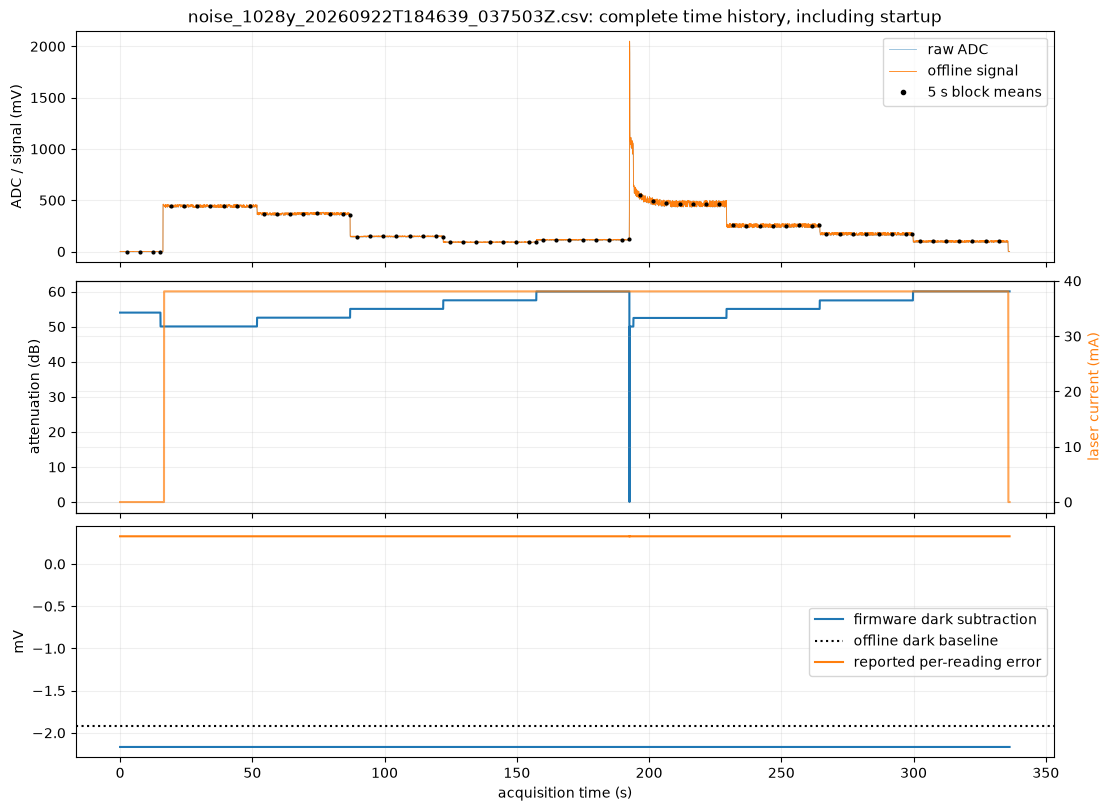

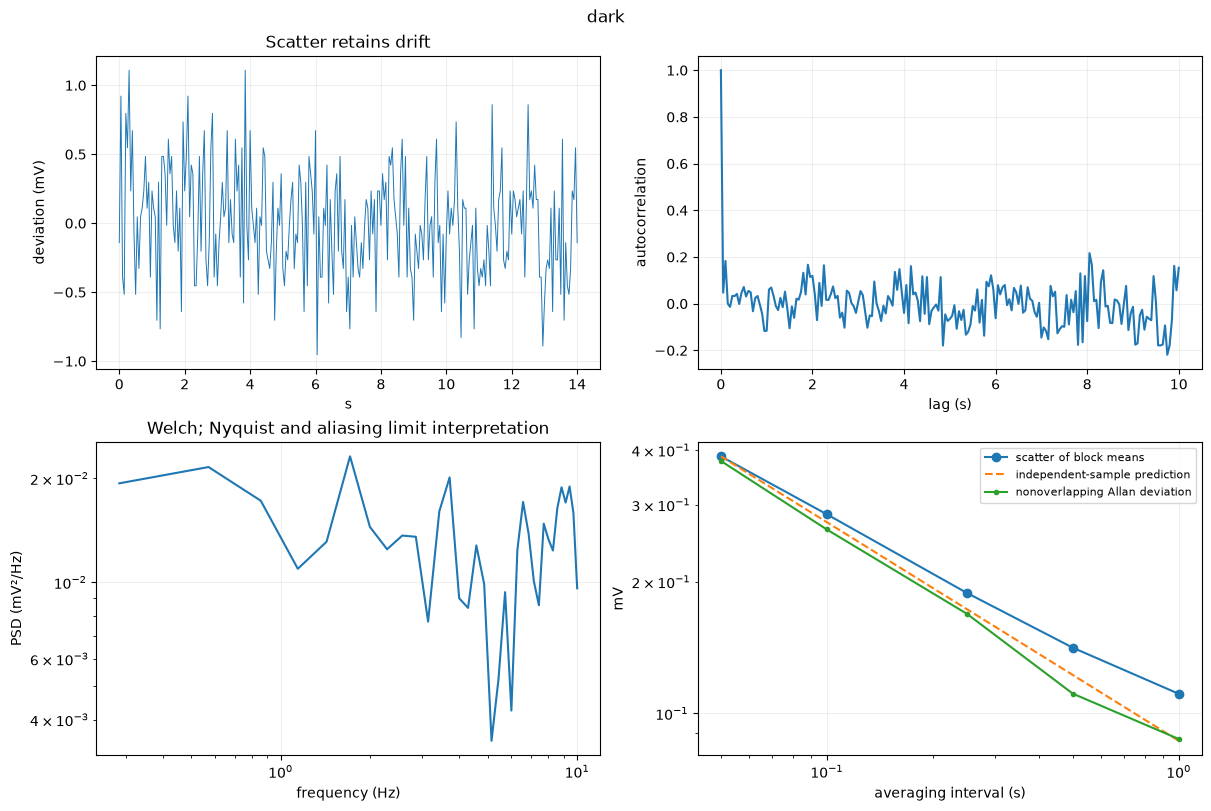

,tau_s,blocks,rms_mean_mv,iid_rms_mean_mv,empirical_se_mv,adjacent_block_corr,allan_mv
0,0.05,281,0.387065,0.387065,0.023090,0.046951,0.377780
1,0.10,140,0.285292,0.273696,0.024112,0.137207,0.263337
2,0.25,56,0.188534,0.173101,0.025194,0.193332,0.168933
3,0.50,28,0.141312,0.122401,0.026706,0.318056,0.110946
4,1.00,14,0.110853,0.086550,0.029627,0.272537,0.087382


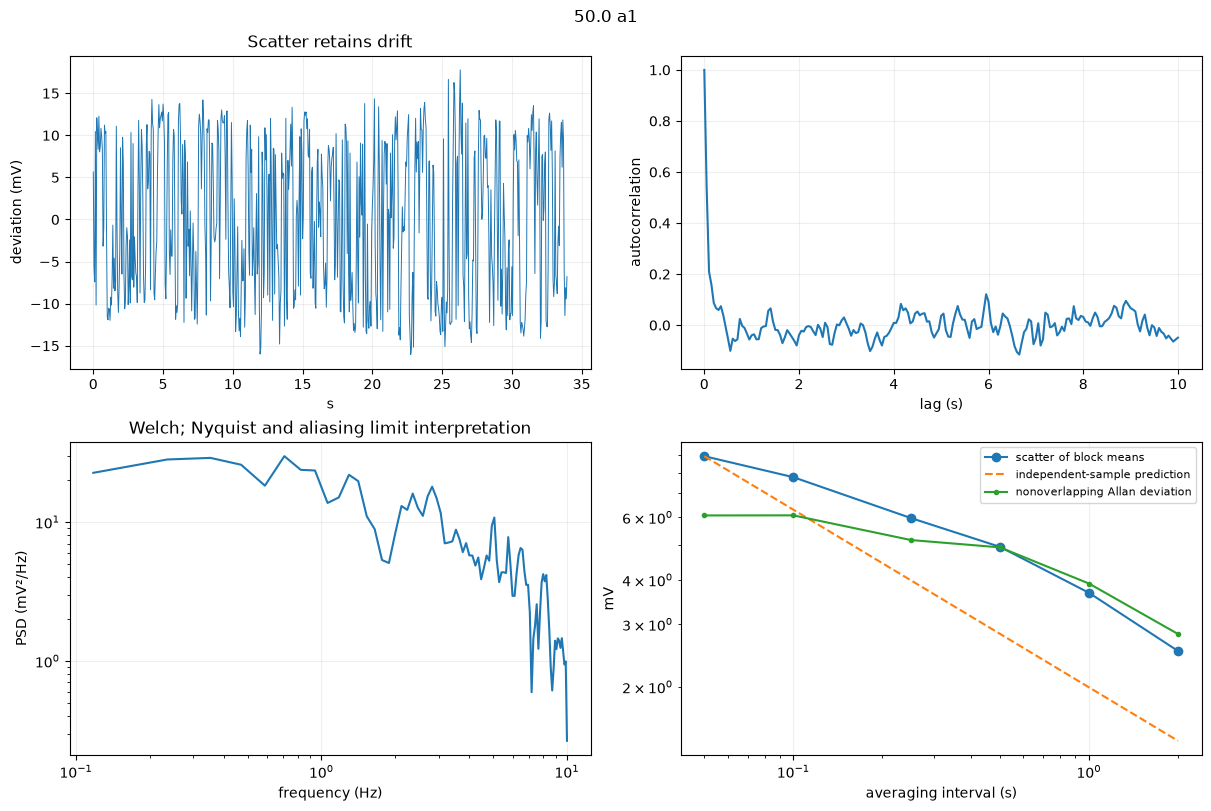

,tau_s,blocks,rms_mean_mv,iid_rms_mean_mv,empirical_se_mv,adjacent_block_corr,allan_mv
0,0.05,680,8.909272,8.909272,0.341655,0.535730,6.068359
1,0.10,340,7.776082,6.299807,0.421717,0.389368,6.071600
2,0.25,136,5.965865,3.984348,0.511569,0.242208,5.173973
3,0.50,68,4.950643,2.817359,0.600354,0.000613,4.934324
4,1.00,34,3.675232,1.992174,0.630297,-0.166959,3.903161
5,2.00,17,2.521442,1.408680,0.611539,-0.247517,2.814766


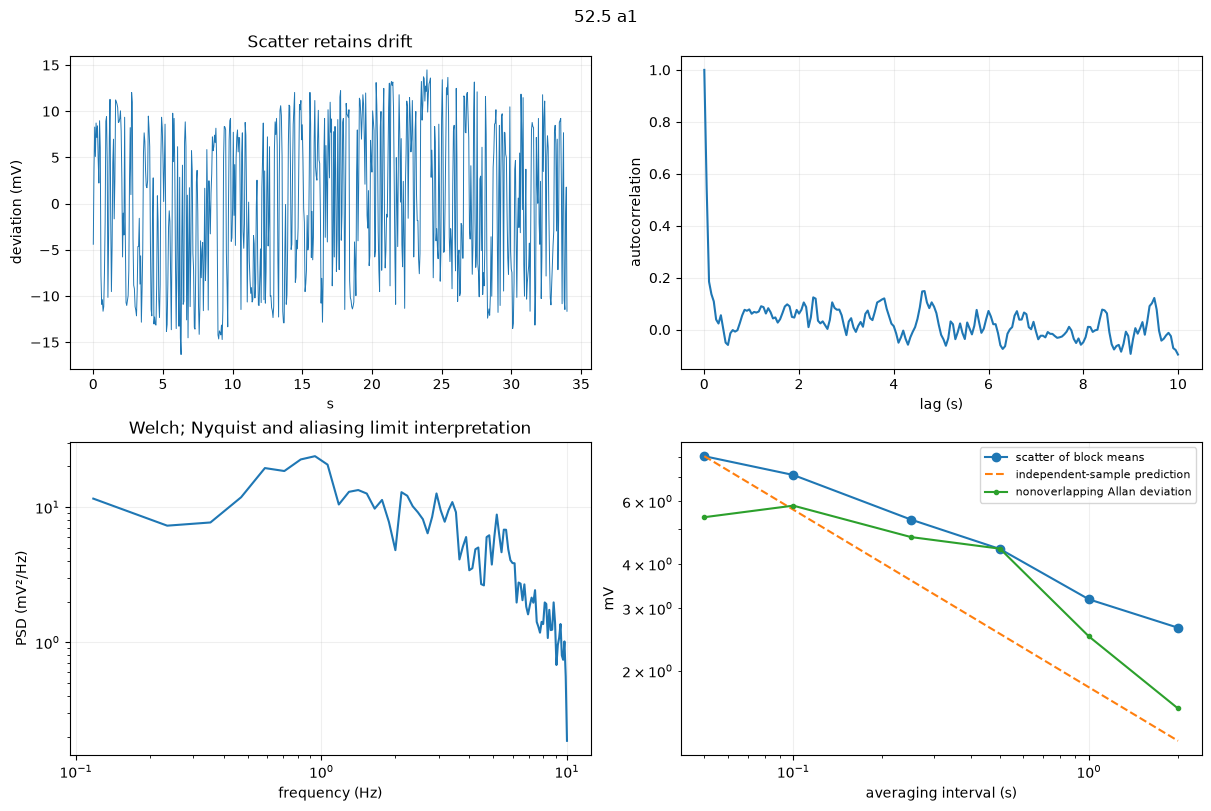

,tau_s,blocks,rms_mean_mv,iid_rms_mean_mv,empirical_se_mv,adjacent_block_corr,allan_mv
0,0.05,681,8.036248,8.036248,0.307950,0.545779,5.411325
1,0.10,340,7.114288,5.682485,0.385826,0.327904,5.832379
2,0.25,136,5.329040,3.593919,0.456961,0.200193,4.757921
3,0.50,68,4.403885,2.541285,0.534049,-0.015030,4.412836
4,1.00,34,3.177723,1.796960,0.544975,0.380878,2.498016
5,2.00,17,2.644375,1.270642,0.641355,0.639610,1.567284


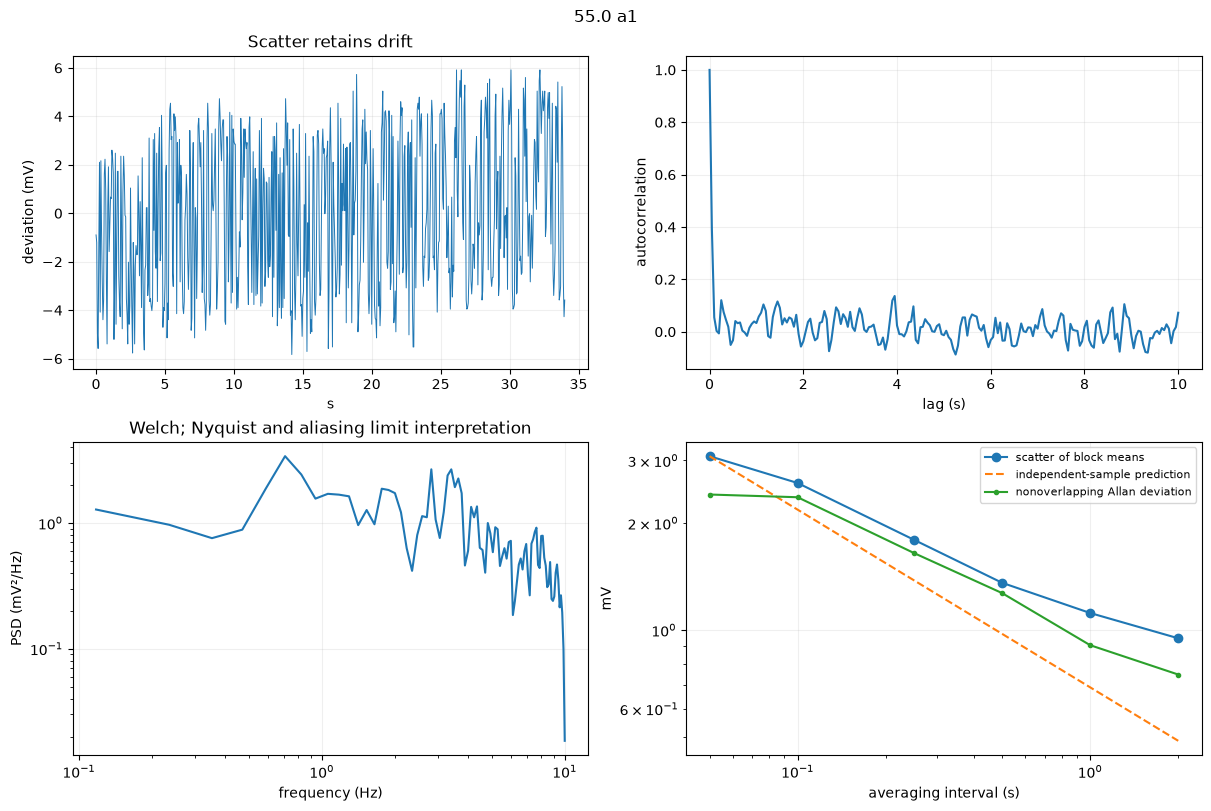

,tau_s,blocks,rms_mean_mv,iid_rms_mean_mv,empirical_se_mv,adjacent_block_corr,allan_mv
0,0.05,681,3.083464,3.083464,0.118159,0.390991,2.405038
1,0.10,340,2.591413,2.180338,0.140539,0.165911,2.363116
2,0.25,136,1.793299,1.378967,0.153774,0.149622,1.645808
3,0.50,68,1.357406,0.975077,0.164610,0.114031,1.269816
4,1.00,34,1.116011,0.689484,0.191394,0.324894,0.905956
5,2.00,17,0.947467,0.487538,0.229794,0.271668,0.749062


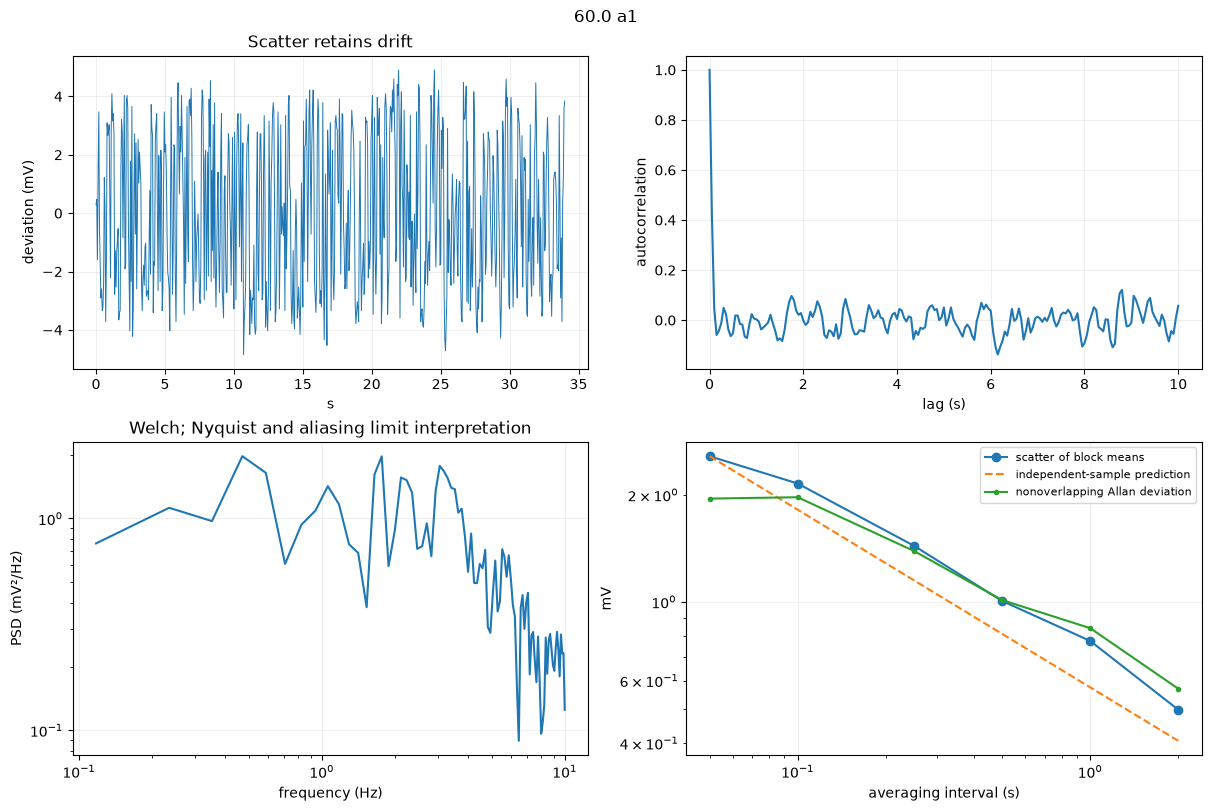

,tau_s,blocks,rms_mean_mv,iid_rms_mean_mv,empirical_se_mv,adjacent_block_corr,allan_mv
0,0.05,681,2.567850,2.567850,0.098400,0.421843,1.950890
1,0.10,340,2.151029,1.815744,0.116656,0.161384,1.967951
2,0.25,136,1.436559,1.148377,0.123184,0.064151,1.388870
3,0.50,68,1.004893,0.812025,0.121861,-0.015291,1.010553
4,1.00,34,0.775663,0.574189,0.133025,-0.187539,0.842598
5,2.00,17,0.496703,0.406013,0.120468,-0.343405,0.569181


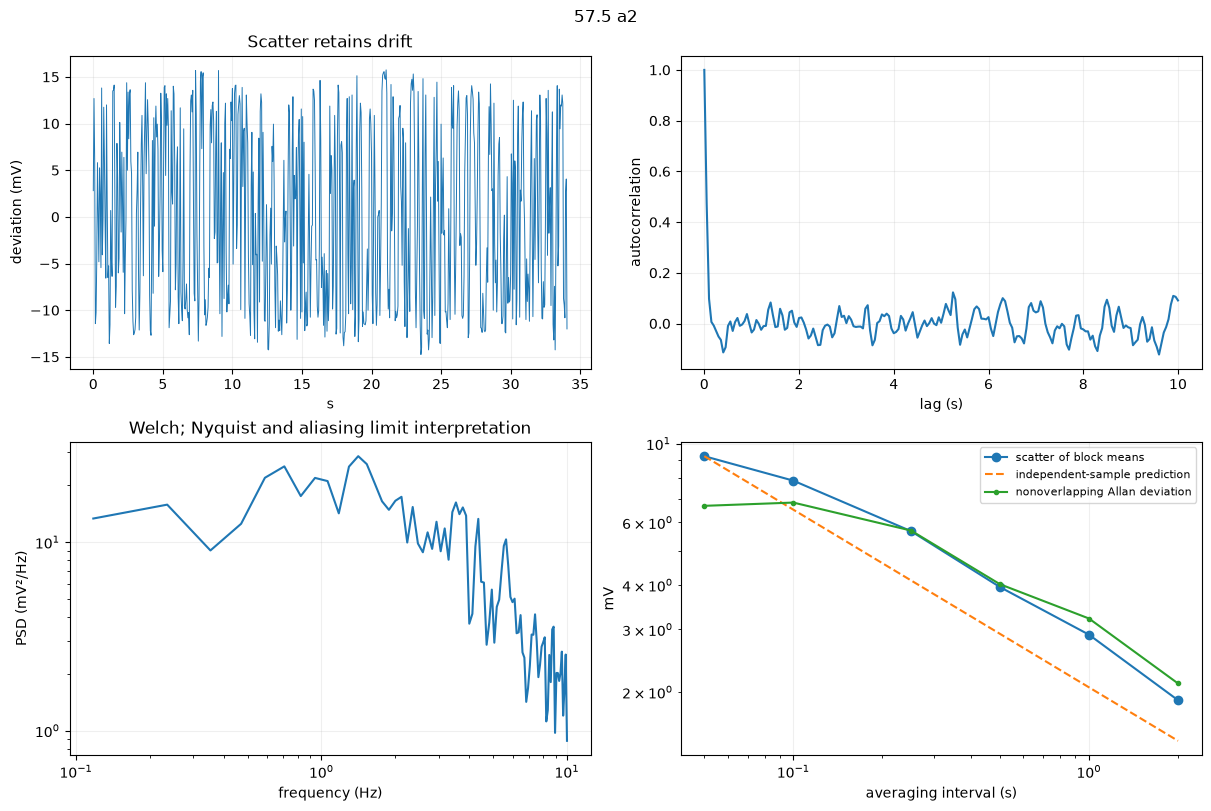

,tau_s,blocks,rms_mean_mv,iid_rms_mean_mv,empirical_se_mv,adjacent_block_corr,allan_mv
0,0.05,682,9.215249,9.215249,0.352870,0.473892,6.679746
1,0.10,341,7.864083,6.516165,0.425864,0.246003,6.822487
2,0.25,136,5.670007,4.121185,0.486199,-0.008595,5.691653
3,0.50,68,3.945829,2.914118,0.478502,-0.048166,4.019341
4,1.00,34,2.898329,2.060592,0.497059,-0.241073,3.218754
5,2.00,17,1.895850,1.457059,0.459811,-0.249960,2.113367


PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=87.030 threshold_mv=10.000 uptime_ms=1116631
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=614.119 threshold_mv=10.000 uptime_ms=1296431
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=457.192 threshold_mv=10.000 uptime_ms=1828031
PCB warning photodiode_noise: photodiode fixed-window RMS exceeded warning threshold context=channel=yj fixed_rms_mv=27.772 threshold_mv=10.000 uptime_ms=1888031


In [8]:
if not data.empty:
    t = (data.t_ms-data.t_ms.iloc[0])/1000
    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(11, 8), layout="constrained")
    axes[0].plot(t, data.pd_mv, lw=.6, alpha=.5, label="raw ADC")
    if np.isfinite(baseline_mv):
        axes[0].plot(t, data.analysis_net_mv, lw=.6, label="offline signal")
    for part in fixed_setting_segments(data, settle_s=0):
        block = ((part.t_ms-part.t_ms.iloc[0])/5000).astype(int)
        means = part.groupby(block).agg(t_ms=("t_ms", "mean"), raw_mv=("pd_mv", "mean"))
        axes[0].plot((means.t_ms-data.t_ms.iloc[0])/1000,
                     means.raw_mv-(baseline_mv if np.isfinite(baseline_mv) else 0), "k.", markersize=4)
    axes[0].plot([], [], "k.", label="5 s block means")
    axes[0].set(ylabel="ADC / signal (mV)", title=f"{source_csv.name}: complete time history, including startup")
    axes[0].legend()
    axes[1].plot(t, data.atten_db, label="reported total attenuation")
    axes[1].set_ylabel("atten setting (dB)")
    right = axes[1].twinx()
    right.plot(t, data.laser_current_ma, color="tab:orange", alpha=.7)
    right.set_ylabel("laser current (mA)", color="tab:orange")
    axes[2].plot(t, data.pd_mv-data.pd_net_mv, label="firmware dark subtraction")
    if np.isfinite(baseline_mv):
        axes[2].axhline(baseline_mv, color="black", ls=":", label="offline dark baseline")
    if "pd_net_err_mv" in data:
        axes[2].plot(t, data.pd_net_err_mv, label="reported per-reading error")
    axes[2].set(xlabel="acquisition time (s)", ylabel="mV")
    axes[2].legend()
    plt.show()

for INTERVAL in [0,1,2,3, 5,8]:
#INTERVAL = 0  # Select from the summary; never concatenate separated intervals for spectra.
    if INTERVAL < len(statistics):
        stats, part = statistics[INTERVAL], segments[INTERVAL]
        if stats["timing_jitter_rms_ms"] > .05*1000/stats["fs_hz"]:
            print("Timing jitter exceeds 5% of cadence; FFT frequency estimates are approximate.")
        fig, axes = plt.subplots(2, 2, figsize=(12, 8), layout="constrained")
        t = (part.t_ms-part.t_ms.iloc[0])/1000
        axes[0, 0].plot(t, part.pd_mv-part.pd_mv.mean(), lw=.7)
        axes[0, 0].set(xlabel="s", ylabel="deviation (mV)", title="Scatter retains drift")
        lag = np.arange(len(stats["acf"]))/stats["fs_hz"]
        axes[0, 1].plot(lag[lag<=10], stats["acf"][lag<=10])
        axes[0, 1].set(xlabel="lag (s)", ylabel="autocorrelation")
        f, psd = stats["frequencies"], stats["psd"]
        axes[1, 0].loglog(f[1:], psd[1:])
        axes[1, 0].set(xlabel="frequency (Hz)", ylabel="PSD (mV²/Hz)", title="Welch; Nyquist and aliasing limit interpretation")
        b = stats["blocks"]
        axes[1, 1].loglog(b.tau_s, b.rms_mean_mv, "o-", label="scatter of block means")
        axes[1, 1].loglog(b.tau_s, b.iid_rms_mean_mv, "--", label="independent-sample prediction")
        axes[1, 1].loglog(b.tau_s, b.allan_mv, ".-", label="nonoverlapping Allan deviation")
        axes[1, 1].set(xlabel="averaging interval (s)", ylabel="mV")
        axes[1, 1].legend(fontsize=8)
        plt.suptitle(summary['label'][INTERVAL])
        plt.show()
        display(b)

# Direct-voltage repeat: retain startup above, compare later visits over their final 30 s.
repeat_rows = []
if not data.empty and noise_meta.get("command_units") == "mv":
    for part in fixed_setting_segments(data, settle_s=0):
        index = int(part.step_index.iloc[0])
        if index <= 1 or part.t_ms.iloc[-1]-part.t_ms.iloc[0] < 30000:
            continue
        tail = part.loc[part.t_ms >= part.t_ms.iloc[-1]-30000]
        state = next(s["state"] for s in noise_meta["steps"] if s["index"] == index)
        first10 = tail.loc[tail.t_ms < tail.t_ms.iloc[0]+10000, "pd_mv"].mean()
        last10 = tail.loc[tail.t_ms > tail.t_ms.iloc[-1]-10000, "pd_mv"].mean()
        repeat_rows.append(dict(label=part.step_label.iloc[0], dac1_mv=state["v1_mv"], dac2_mv=state["v2_mv"],
            mean_mv=tail.analysis_net_mv.mean(), rms_mv=tail.pd_mv.std(), drift_mv=last10-first10))
    if repeat_rows:
        repeat_table = pd.DataFrame(repeat_rows)
        positive = repeat_table.mean_mv.where(repeat_table.mean_mv > 0)
        repeat_table["signal_ratio_to_previous_visit"] = positive/positive.shift()
        repeat_table["change_db_from_previous_visit"] = -10*np.log10(repeat_table.signal_ratio_to_previous_visit)
        first_same = repeat_table.groupby(["dac1_mv", "dac2_mv"]).mean_mv.transform("first")
        repeat_table["signal_ratio_to_first_same_setting"] = positive/first_same.where(first_same > 0)
        display(repeat_table)
        print("Startup A excluded here. Drift = last 10 s minus first 10 s of each final-30-second window.")
        print("Ratios describe measured repeatability and reversal; no device-failure threshold is applied.")

The block table's `empirical_se_mv` divides the scatter of block means by sqrt(number of blocks).
That estimates uncertainty of the full-record mean **only if the blocks are effectively independent
and the process is sufficiently stationary**. Inspect adjacent-block correlation and stability across
block sizes; drift and too few long blocks can invalidate it. Allan deviation is another view of
averaging stability, not automatically an error bar on a mean. No calibration term is divided by √N.

The 20 Hz stream has a ~10 Hz Nyquist frequency. The nominal 20 Hz analog RC does not prevent all
aliasing. Spectra describe sampled fluctuations; they cannot recover the unsampled drive spectrum.

### Noise versus brightness and the shot-noise scale

For ADC-input effective transimpedance $G$, mean signal $V$ and equivalent noise bandwidth $B$,
the elementary photocurrent shot-noise estimate is $\sigma_V=\sqrt{2qGV B}$.
`B` is **equivalent noise bandwidth**, not necessarily an RC cutoff or the stream rate. The values
below are scenarios; filter cascades and aliasing require the real transfer functions.

Compare the repeated reference first. A variance model fitted across drifting records or different
FVOA allocations can mistake changes in the experiment for photon statistics. The reference lines
are proportionality comparisons, not a claim to have separated noise sources.

,interval,enbw_hz,shot_rms_mv,observed_rms_mv,ratio
0,0,5.0,3.182491e-11,0.387065,1.216234e+10
1,0,10.0,4.500722e-11,0.387065,8.600070e+09
2,0,20.0,6.364981e-11,0.387065,6.081168e+09
3,0,40.0,9.001443e-11,0.387065,4.300035e+09
4,1,5.0,1.192902e-01,8.909272,7.468569e+01
5,1,10.0,1.687018e-01,8.909272,5.281076e+01
6,1,20.0,2.385804e-01,8.909272,3.734285e+01
7,1,40.0,3.374037e-01,8.909272,2.640538e+01
8,2,5.0,1.087580e-01,8.036248,7.389111e+01
9,2,10.0,1.538070e-01,8.036248,5.224890e+01


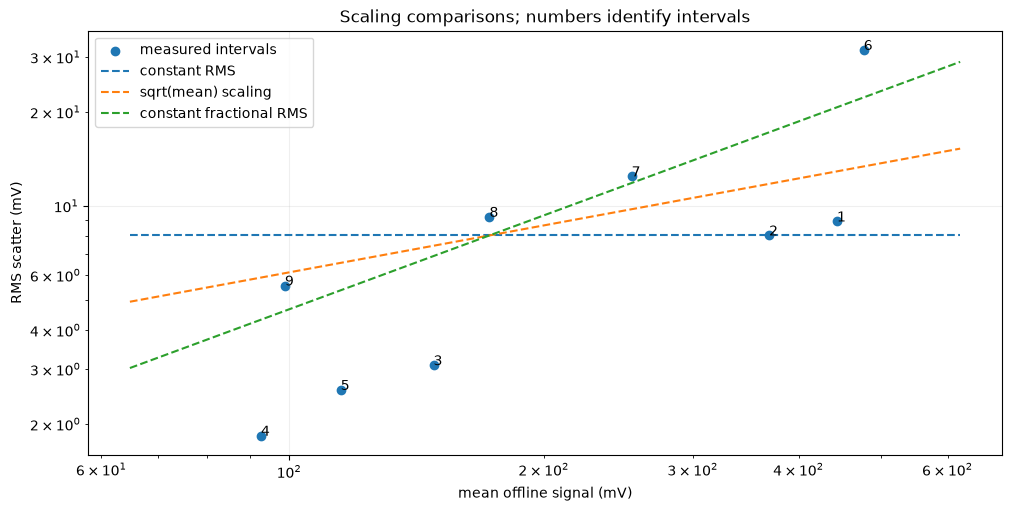

In [9]:
ENBW_SCENARIOS_HZ = np.array([5.0, 10.0, 20.0, 40.0])
q_e = 1.602176634e-19
shot_rows = []
if statistics:
    for i, stats in enumerate(statistics):
        if not np.isfinite(stats["mean_mv"]) or stats["mean_mv"] <= 0:
            continue
        for bandwidth in ENBW_SCENARIOS_HZ:
            shot_mv = np.sqrt(2*q_e*EFFECTIVE_GAIN_V_PER_A*(stats["mean_mv"]/1000)*bandwidth)*1000
            shot_rows.append(dict(interval=i, enbw_hz=bandwidth, shot_rms_mv=shot_mv,
                                  observed_rms_mv=stats["rms_mv"], ratio=stats["rms_mv"]/shot_mv))
    display(pd.DataFrame(shot_rows))
    bright = summary.loc[summary.mean_mv > 3*summary.rms_mv]
    if not bright.empty:
        fig, ax = plt.subplots(layout="constrained")
        ax.scatter(bright.mean_mv, bright.rms_mv, label="measured intervals")
        for row in bright.itertuples():
            ax.annotate(str(row.interval), (row.mean_mv, row.rms_mv))
        mu0, rms0 = bright.mean_mv.median(), bright.rms_mv.median()
        mu = np.geomspace(max(bright.mean_mv.min()*.7, .01), bright.mean_mv.max()*1.3, 200)
        for exponent, label in [(0, "constant RMS"), (.5, "sqrt(mean) scaling"), (1, "constant fractional RMS")]:
            ax.plot(mu, rms0*(mu/mu0)**exponent, "--", label=label)
        ax.set(xscale="log", yscale="log", xlabel="mean offline signal (mV)", ylabel="RMS scatter (mV)", title="Scaling comparisons; numbers identify intervals")
        ax.legend()
        plt.show()
else:
    print("Shot-noise and brightness comparisons need fixed-setting records; no historical summary substituted.")

### Throughput and uncertainty accounting

The stream applies its captured return factor to `pd_power_nw` and launch factor to
`delivered_power_nw`. Audit this arithmetic using the recorded factors. Their physical accuracy
depends on the assembled path and calibration described in the capture's setup notes.

Recorded throughput and uncertainties remain firmware values. A contaminated or unverified dark
prevents their physical interpretation even when the arithmetic agrees. Offline signal statistics
use the baseline above; multiplying already zero-clipped throughput cannot repair a bad subtraction.
An optional associated power-meter value replaces only the source-power estimate and uses the same
captured route factors. No bypass geometry or additional path loss is assumed.

,tp_max_abs_arithmetic_difference,tp_pd_err_max_abs_difference,tp_err_max_abs_difference,median_recorded_launch_tx,median_recorded_return_tx,firmware_dark_usable
0,1.350884e-10,1.142142e-13,4.568079e-11,0.000008,0.98,True


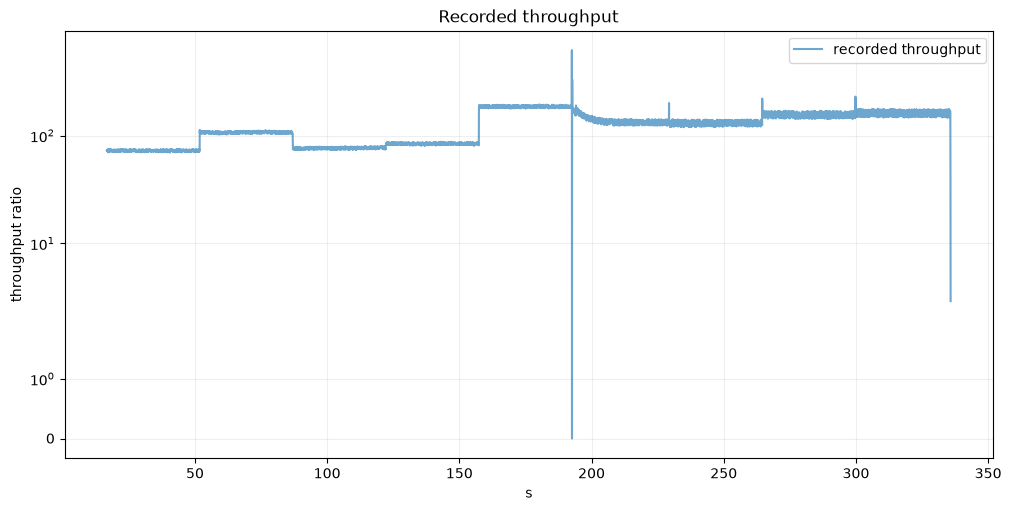

,interval,measured_scatter_mv,reported_pd_error_mv,block_duration_s,block_mean_scatter_mv,source_uncertainty_fraction
0,0,0.387065,0.327692,1.0,0.110853,NaN
1,1,8.909272,0.327692,1.0,3.675232,0.190500
2,2,8.036248,0.327692,1.0,3.177723,0.197666
3,3,3.083464,0.327692,1.0,1.116011,0.221297
4,4,1.832605,0.327692,1.0,0.558755,0.226014
5,5,2.567850,0.327692,1.0,0.775663,0.230731
6,6,31.582120,0.327692,1.0,24.721606,0.134099
7,7,12.426842,0.327692,1.0,3.961955,0.168714
8,8,9.215249,0.327692,1.0,2.898329,0.172146
9,9,5.550630,0.327692,1.0,1.575326,0.175677


Source uncertainty may include the firmware's assumed electrical-noise term; it is not all shared calibration error.


In [10]:
audit_fields = {"tp", "tp_err", "tp_pd_err", "pd_power_nw", "pd_power_err_nw",
    "delivered_power_nw", "delivered_power_err_nw", "pd_route_tx", "laser_route_tx", "atten_tx"}
if not data.empty and audit_fields <= set(data):
    d = data.loc[np.isfinite(data.delivered_power_nw) & (data.delivered_power_nw > 0)].copy()
    with np.errstate(divide="ignore", invalid="ignore"):
        reconstructed_tp = d.pd_power_nw/d.delivered_power_nw
        reconstructed_pd_err = d.pd_power_err_nw/d.delivered_power_nw
        reconstructed_err = np.hypot(reconstructed_pd_err,
            reconstructed_tp*d.delivered_power_err_nw/d.delivered_power_nw)
    display(pd.DataFrame([dict(
        tp_max_abs_arithmetic_difference=float((d.tp-reconstructed_tp).abs().max()),
        tp_pd_err_max_abs_difference=float((d.tp_pd_err-reconstructed_pd_err).abs().max()),
        tp_err_max_abs_difference=float((d.tp_err-reconstructed_err).abs().max()),
        median_recorded_launch_tx=d.laser_route_tx.median(), median_recorded_return_tx=d.pd_route_tx.median(),
        firmware_dark_usable=firmware_dark_usable)]))
    fig, ax = plt.subplots(layout="constrained")
    t = (d.t_ms-data.t_ms.iloc[0])/1000
    ax.plot(t, d.tp, label="recorded throughput", alpha=.65)
    if EXTERNAL_LASER_POWER_MW is not None and firmware_dark_usable:
        if not EXTERNAL_LASER_POWER_MW > 0:
            raise ValueError("Power-meter reading must be positive.")
        meter_denominator = EXTERNAL_LASER_POWER_MW*1e6*d.atten_tx*d.laser_route_tx
        ax.plot(t, d.pd_power_nw/meter_denominator, label="recorded routes + supplied power-meter value")
    ax.set(yscale="symlog", ylabel="throughput ratio", xlabel="s", title="Recorded throughput" if firmware_dark_usable else "Recorded throughput: dark unusable/unverified")
    ax.legend()
    plt.show()
else:
    print("Current power/error fields unavailable; route/error audit skipped.")

error_rows = []
for i,(part,stats) in enumerate(zip(segments, statistics)):
    b = stats["blocks"]
    one = b.iloc[np.argmin(abs(b.tau_s-1))] if len(b) else None
    error_rows.append(dict(interval=i, measured_scatter_mv=stats["rms_mv"],
        reported_pd_error_mv=part.pd_net_err_mv.median() if "pd_net_err_mv" in part else np.nan,
        block_duration_s=one.tau_s if one is not None else np.nan,
        block_mean_scatter_mv=one.rms_mean_mv if one is not None else np.nan,
        source_uncertainty_fraction=(part.delivered_power_err_nw/part.delivered_power_nw.where(part.delivered_power_nw>0)).median()
            if "delivered_power_err_nw" in part else np.nan))
if error_rows:
    display(pd.DataFrame(error_rows))
    print("Source uncertainty may include the firmware's assumed electrical-noise term; it is not all shared calibration error.")

Near darkness, tiny positive zero-clipped power or throughput is not evidence of a detection.
Use the signed voltage, a nearby dark trace, and measured averaging stability. The noise summary
suppresses fractional RMS when the mean is below three times the individual-reading scatter;
that is a descriptive reporting threshold, not a calibrated significance test for a time average.

To investigate a large absolute throughput offset, check the power meter, responsivity/effective
gain, static attenuation, and couplings after correcting geometry. The new electrical-noise term
does not correct an erroneous mean denominator.

When local candidate voltage commands were used, firmware still reports attenuation and throughput
using its installed coefficients. The additional experimental-curve line explicitly replaces that
dynamic attenuation factor offline; it is a candidate estimate, not an independent power measurement.

<a id="scope"></a>
## 5. Local slopes: how much voltage noise would matter?

All scope voltages below are **post-amplifier FVOA-control mV**, not DAC mV. Let
$s_i=dA_i/dV_i$ be dB per FVOA mV and $k=\ln(10)/10$. At frequencies where the optical response follows
the drive, the predicted fractional intensity variance is

$$\sigma_{rel}^2=k^2\left[(s_1\sigma_1)^2+(s_2\sigma_2)^2+
2\rho s_1s_2\sigma_1\sigma_2\right].$$

The equal-independent-drive inversion is only an **equivalent voltage noise**: it attributes all
remaining optical scatter to the drives. It does not measure the drives or prove causality.
Stored fit residuals describe curve uncertainty and are not added to temporal RMS here.

In [11]:
def drive_slopes(coefficients, dac_mv):
    slopes = []
    for physical, mv in zip(("dac1", "dac2"), dac_mv):
        coeff = coefficients[physical]
        gain = float(coeff["gain"])
        x = float(mv) + np.array([-.1, .1])/gain
        db = hspcb._atten_db_from_coeff((coeff["fvoa_50pct_mv"], coeff["slope_inv_fvoa_mv"],
            coeff["max_atten_db"], gain, tuple(coeff["correction_coeff"]),
            float(coeff.get("max_calibrated_db", 0.0))), x)
        slopes.append(float((db[1]-db[0])/.2))
    return np.asarray(slopes)


equivalent_rows = []
noise_context = noise_meta.get("context", {})
coefficients = noise_context.get("coeff")
dark_stats = [stats for part,stats in zip(segments, statistics)
              if "step_label" in part and part.step_label.iloc[0] == "dark"]
dark_rms = dark_stats[0]["rms_mv"] if dark_stats else np.nan
for i,(part,stats) in enumerate(zip(segments, statistics)):
    if coefficients is None or "step_index" not in part or not np.isfinite(stats["relative_rms"]):
        continue
    step = next(s for s in noise_meta["steps"] if s["index"] == int(part.step_index.iloc[0]))
    if step["label"] == "dark":
        continue
    state = step["state"]
    slopes = drive_slopes(coefficients, (state["v1_mv"], state["v2_mv"]))
    scale = np.log(10)/10
    excess = np.sqrt(max(stats["rms_mv"]**2-dark_rms**2, 0)) if np.isfinite(dark_rms) else stats["rms_mv"]
    equivalent = excess/abs(stats["mean_mv"])/(scale*np.linalg.norm(slopes)) if np.linalg.norm(slopes)>0 else np.nan
    equivalent_rows.append(dict(interval=i, step=step["label"], mv=stats["mean_mv"], rms_mv=stats["rms_mv"], slope1_db_per_fvoa_mv=slopes[0],
        slope2_db_per_fvoa_mv=slopes[1], equivalent_equal_independent_rms_mv=equivalent,
        rms_over_mean=stats["relative_rms"], predicted_fraction_at_1mv=scale*np.linalg.norm(slopes),
        installed_curve_sigma_fraction=scale*np.hypot(coefficients["dac1"]["rms_db"], coefficients["dac2"]["rms_db"])))
if equivalent_rows:
    display(pd.DataFrame(equivalent_rows))
else:
    print("Slope/noise inference needs a capture sidecar with coefficients and actual per-FVOA DAC positions.")

# Static sensitivity scenarios. None means no actual scope RMS has been supplied.
SCOPE_RMS_MV = None  # e.g. (sigma1, sigma2), measured RMS in the stated relevant bandwidth.
DRIVE_CORRELATION = 0.0
if SCOPE_RMS_MV is not None and equivalent_rows:
    if len(SCOPE_RMS_MV) != 2 or min(SCOPE_RMS_MV) < 0 or not -1 <= DRIVE_CORRELATION <= 1:
        raise ValueError("Supply two nonnegative RMS values and a correlation from -1 to 1.")
    s = equivalent_rows[0]
    a,b = np.array([s["slope1_db_per_fvoa_mv"],s["slope2_db_per_fvoa_mv"]])*SCOPE_RMS_MV
    predicted = np.log(10)/10*np.sqrt(max(a*a+b*b+2*DRIVE_CORRELATION*a*b, 0))
    print(f"Static prediction for interval {s['interval']}: {100*predicted:.2f}% RMS; bandwidth assumptions still apply.")

,interval,step,mv,rms_mv,slope1_db_per_fvoa_mv,slope2_db_per_fvoa_mv,equivalent_equal_independent_rms_mv,rms_over_mean,predicted_fraction_at_1mv,installed_curve_sigma_fraction
0,1,50.0 a1,444.088252,8.909272,0.079365,0.000000,1.096772,0.020062,0.018275,0.044004
1,2,52.5 a1,369.132152,8.036248,0.082604,0.000000,1.143270,0.021771,0.019020,0.044004
2,3,55.0 a1,148.128022,3.083464,0.093225,0.000000,0.962067,0.020816,0.021466,0.044004
3,4,57.5 a1,92.626279,1.832605,0.095335,0.000000,0.880958,0.019785,0.021952,0.044004
4,5,60.0 a1,115.076627,2.567850,0.097443,0.000000,0.983162,0.022314,0.022437,0.044004
5,6,52.5 a2,477.636598,31.582120,0.000000,0.053346,5.382618,0.066122,0.012283,0.044004
6,7,55.0 a2,253.957999,12.426842,0.000000,0.069446,3.058605,0.048933,0.015991,0.044004
7,8,57.5 a2,172.486133,9.215249,0.000000,0.071017,3.264301,0.053426,0.016352,0.044004
8,9,60.0 a2,98.869594,5.550630,0.000000,0.072630,3.348799,0.056141,0.016724,0.044004


## 6. What evidence would change the design?

| Observation | Interpretation / next check |
|---|---|
| Firmware chooses fewer correction terms | Inspect calibrated-region residuals; the higher-order correction failed the curve check. |
| Firmware reports base-only fit | Inspect its residuals and rejection warning before relying on dB accuracy. |
| Initial reference and first sweep reading disagree at the same settings | Inspect the chronological probe table and acquisition timing; the cause remains unresolved. |
| Equal-total allocations change fractional noise with local slopes | Consistent with drive sensitivity; compare actual detector levels and simultaneous voltage spectra. |
| Drive and analog-PD spectra are coherent at the excess-noise frequencies | Quantify gain, phase and both-drive covariance; test filtering in that band. Coherence alone does not establish causality. |
| Analog PD is quiet while ADC varies | Investigate detector-output-to-ADC path, reference, pickup and conversion configuration. |
| Analog PD varies without resolved drive variation | Bound the scope floor; investigate actuator/mechanical/thermal or detector multiplicative noise. |
| Repeated reference settings drift | Separate drift from stationary noise; use longer repeats and logged temperature before fitting a brightness law. |
| A dark capture clips immediately after detector power-up | Inspect startup; reject it before illumination and compare the later dark trace. |
| A fixed-voltage repeat brightens at the higher voltage after settling | Inspect repeatability, history and drift before setting a calibration-failure threshold. |
| Raw measurements exceed the selected reference | Keep signed residuals; a reference offset alone is not a hardware diagnosis. |

Before changing an op-amp/DAC filter, establish how much **in-band** voltage variation accounts for
the optical scatter. The present evidence motivates that measurement; it does not establish a PCB respin.
The capacitor comparison needs matched conditions before/after the change. Both FVOAs remain
in the path, and a noisier DAC2 configuration does not by itself identify the DAC1 capacitor.

### References in this workspace

- [Current calibration and acquisition](../doc/attenuator_calibration.md)
- [Photodiode sampling and uncertainty assumptions](../doc/photodiode_notes.md)
- [Installed attenuator slope/noise calculation](../doc/api/attenuator_control.md)
- [Command/API units and side effects](../doc/commands.md)
- [Analog hardware and gain locations](../doc/hardware.md)